In [1]:
import os, json, math, warnings
import numpy as np
import pandas as pd
import dask.dataframe as dd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
import seaborn as sns
import geopandas as gpd
from scipy import stats as scipy_stats

warnings.filterwarnings("ignore")
plt.rcParams.update({
    "figure.dpi": 100, 
    "font.family": "DejaVu Sans",
    "axes.spines.top": False, 
    "axes.spines.right": False
})

# ── Paths ──────────────────────────────────────────────────────────────
MLAB_DIR     = "../../data/ndt7/raw/mlab_results/"
CLIENT_PKT   = "../../data/ndt7/raw/client_complete.parquet"
CITY_JSON    = "../../data/ndt7/raw/city_to_province.json"
GEOJSON      = "../../data/geo/thailand_provinces.geojson"
PROV_REF_CSV = "../../data/reference/province_reference.csv"
OOKLA_CSV    = "../../data/ndt7/ookla_province_summary.csv"

# ── Ookla tile config ──────────────────────────────────────────────────
ZOOM          = 16
N_TILES       = 2 ** ZOOM
MIN_TILE_TESTS = 3

# ── ISP lists ─────────────────────────────────────────────────────────
VALID_ISP_BB   = {"AIS", "TRUE", "3BB", "CAT", "NT", "Cableconnect", "Sophon"}
VALID_ISP_CELL = {"AIS", "TRUE", "DTAC", "NT"}

# ── Color ramps ───────────────────────────────────────────────────────
OOKLA_CMAP = mcolors.LinearSegmentedColormap.from_list(
    "ookla", ["#d7191c","#fdae61","#ffffbf","#a6d96a","#1a9641"]
)
REGION_COLORS = {
    'Bangkok & Vicinity': '#e63946',
    'Eastern':            '#f4a261',
    'Central':            '#2a9d8f',
    'Western':            '#8338ec',
    'Northern':           '#457b9d',
    'Southern':           '#ffb703',
    'Northeastern':       '#6d6875',
}

print("Config loaded ✓")

Config loaded ✓


## 1 — Load & Clean Raw M-Lab Data
*Dask-based raw log ingestion, client enrichment, and city-to-province mapping.*


In [ ]:
# Load raw logs and merge with client info
result_ddf = dd.read_parquet(MLAB_DIR)
result_ddf = result_ddf.dropna(subset=["id","date","city","mean_throughput_mbps","type"])
result_ddf["city"] = result_ddf["city"].str.strip().str.title()

client_ddf = dd.read_parquet(CLIENT_PKT)
client_ddf = client_ddf.map_partitions(lambda df: df.reset_index(drop=True)).drop(columns=["mobile"], errors="ignore")

df_full = dd.merge(result_ddf, client_ddf, on="client_ip", how="left").compute()
print(f"Loaded {len(df_full):,} raw records.")

# Map city to province
with open(CITY_JSON, "r", encoding="utf-8") as f:
    city_map = json.load(f)
df_full["city"] = df_full["city"].map(city_map).fillna(df_full["city"])

df_full = df_full[df_full["mean_throughput_mbps"] > 0]
df_full = df_full.dropna(subset=["latitude","longitude"])

# Date parsing & quarterly labels — format 2023-Q4 to match Ookla
df_full["date"] = pd.to_datetime(df_full["date"])
df_full["year_q"] = (
    df_full["date"].dt.to_period("Q").astype(str)
    .str.replace(r"(\d{4})Q(\d)", r"\1-Q\2", regex=True)
)

# Cap extreme latency outliers (satellite / misconfigured clients) before tile aggregation
df_full["min_rtt"] = df_full["min_rtt"].clip(upper=2000)

print(f"After clean: {len(df_full):,} | Unique Quarters: {sorted(df_full['year_q'].unique())}")
    

## 2 — Slippy Map Tile Assignment (Zoom 16)
*We map tests to zoom-16 tiles (~600m) to correct for test volume bias, matching Ookla's open dataset grid.*


In [ ]:
# Web Mercator projection formulas to assign SMT-16 tile IDs
lat_rad = np.radians(df_full["latitude"].clip(-85.05112878, 85.05112878))
mercator_y = np.log(np.tan(lat_rad) + 1.0 / np.cos(lat_rad))

df_full["tile_x"] = ((df_full["longitude"] + 180) / 360 * N_TILES).astype(int).clip(0, N_TILES-1)
df_full["tile_y"] = ((1 - mercator_y / np.pi) / 2 * N_TILES).astype(int).clip(0, N_TILES-1)
df_full["tile_id"] = df_full["tile_x"].astype(str) + "_" + df_full["tile_y"].astype(str)

print(f"Unique tiles in dataset: {df_full['tile_id'].nunique():,}")


Unique tiles in dataset: 890


## 3 — Tile-Level Aggregation & Spatial Join
*Compute mean, median, latency, and count per tile. Drop tiles with < 3 tests. Spatial join centroids with provinces.*


In [ ]:
# Filter valid ISPs
df_bb = df_full[(df_full["network_type"] == "broadband") & df_full["description"].isin(VALID_ISP_BB)].copy()
df_cell = df_full[(df_full["network_type"] == "cellular") & df_full["description"].isin(VALID_ISP_CELL)].copy()

def aggregate_tiles(df, network_type):
    # Group by key tile characteristics to find tile stats
    agg = df.groupby(["tile_id", "tile_x", "tile_y", "type", "city", "description"]).agg(
        tile_mean=("mean_throughput_mbps", "mean"),
        tile_median=("mean_throughput_mbps", "median"),
        tile_lat=("min_rtt", "mean"),
        test_count=("mean_throughput_mbps", "count")
    ).reset_index()
    
    # Filter by minimum tests threshold
    agg = agg[agg["test_count"] >= MIN_TILE_TESTS].copy()
    agg["network_type"] = network_type
    return agg

print("Aggregating tiles (Broadband & Cellular)...")
bb_tiles = aggregate_tiles(df_bb, "broadband")
cell_tiles = aggregate_tiles(df_cell, "cellular")
tiles_all = pd.concat([bb_tiles, cell_tiles], ignore_index=True)
print(f"Broadband tiles: {len(bb_tiles):,} | Cellular tiles: {len(cell_tiles):,}")

# Spatial Join centroids to province boundaries
thai_gdf = gpd.read_file(GEOJSON).to_crs(epsg=4326)
thai_gdf = thai_gdf.rename(columns={"name": "province_geo"})

n = 2**ZOOM
tile_x_c = tiles_all["tile_x"] + 0.5
tile_y_c = tiles_all["tile_y"] + 0.5
lon_c = tile_x_c / n * 360 - 180
lat_rad_c = np.arctan(np.sinh(np.pi * (1 - 2*tile_y_c/n)))
lat_c = np.degrees(lat_rad_c)

gdf_tiles = gpd.GeoDataFrame(
    tiles_all.copy(),
    geometry=gpd.points_from_xy(lon_c, lat_c),
    crs="EPSG:4326"
)

joined_tiles = gpd.sjoin(gdf_tiles, thai_gdf[["province_geo", "geometry"]], how="left", predicate="within")
joined_tiles["province"] = joined_tiles["province_geo"].fillna(joined_tiles["city"])
joined_tiles = pd.DataFrame(joined_tiles.drop(columns=["geometry", "index_right", "province_geo", "city"], errors="ignore"))

print(f"Spatial join hit rate: {joined_tiles['province'].notna().mean():.1%}")


Aggregating tiles (Broadband & Cellular)...
Broadband tiles: 3,786 | Cellular tiles: 700
Spatial join hit rate: 100.0%


## 4 — Province-Level Weighted Aggregation
*Compute tile-weighted mean and unweighted median of speeds at province level. Enrich with demographic and quarterly reference fields.*


In [ ]:
# Read reference tables
prov_ref = pd.read_csv(PROV_REF_CSV).rename(columns={"province_en": "province"})

def aggregate_province(df):
    # Separate download/upload
    dl = df[df["type"] == "download"]
    ul = df[df["type"] == "upload"]
    
    # DL Stats
    dl_stats = dl.groupby(["province", "network_type"]).apply(lambda g: pd.Series({
        "avg_d_mbps": np.average(g["tile_mean"], weights=g["test_count"]),
        "med_d_mbps": g["tile_median"].median(),
        "avg_lat_ms": np.average(g["tile_lat"], weights=g["test_count"]),
        "med_lat_ms": g["tile_lat"].median(),
        "total_tests": g["test_count"].sum(),
        "num_tiles": g["tile_id"].nunique()
    }), include_groups=False).reset_index()
    
    # UL Stats
    ul_stats = ul.groupby(["province", "network_type"]).apply(lambda g: pd.Series({
        "avg_u_mbps": np.average(g["tile_mean"], weights=g["test_count"]),
        "med_u_mbps": g["tile_median"].median()
    }), include_groups=False).reset_index()
    
    merged = pd.merge(dl_stats, ul_stats, on=["province", "network_type"], how="outer")
    return merged

print("Aggregating to province level...")
prov_master = aggregate_province(joined_tiles)

# Merge reference
prov_master = prov_master.merge(prov_ref, on="province", how="left")

# Ratios and population normalized metrics
prov_master["mean_ratio"] = prov_master["avg_u_mbps"] / prov_master["avg_d_mbps"]
prov_master["med_ratio"]  = prov_master["med_u_mbps"] / prov_master["med_d_mbps"]
prov_master["tests_per_1000_pop"] = prov_master["total_tests"] / prov_master["pop_2024"] * 1000

print(f"Master province stats compiled. Shapes: master = {prov_master.shape}")


Aggregating to province level...
Master province stats compiled. Shapes: master = (137, 20)


In [ ]:
# Quality flag: province needs >= 3 tiles and >= 300 total download tests (avg 50/quarter)
prov_master["is_reliable"] = (
    (prov_master["num_tiles"] >= 3) &
    (prov_master["total_tests"] >= 300)
)
print(f"Reliable provinces: {prov_master[prov_master['is_reliable']]['province'].nunique()} / {prov_master['province'].nunique()}")


Reliable provinces: 77 / 77


In [ ]:
def _reaggregate_quarterly(net_type, include_latency=False):
    """Re-aggregate df_full → province × quarter. Download only, tile-weighted."""
    isp_set = VALID_ISP_BB if net_type == "broadband" else VALID_ISP_CELL
    sub = df_full[
        (df_full["network_type"] == net_type) &
        (df_full["type"] == "download") &
        df_full["description"].isin(isp_set)
    ].copy()

    grp = sub.groupby(["year_q", "tile_id", "tile_x", "tile_y", "city"])
    if include_latency:
        q_tiles = grp.agg(
            t_mean=("mean_throughput_mbps", "mean"),
            t_median=("mean_throughput_mbps", "median"),
            t_count=("mean_throughput_mbps", "count"),
            t_lat=("min_rtt", "mean"),
        ).reset_index()
    else:
        q_tiles = grp.agg(
            t_mean=("mean_throughput_mbps", "mean"),
            t_median=("mean_throughput_mbps", "median"),
            t_count=("mean_throughput_mbps", "count"),
        ).reset_index()
    q_tiles = q_tiles[q_tiles["t_count"] >= MIN_TILE_TESTS]

    n = 2 ** ZOOM
    tile_x_c = q_tiles["tile_x"] + 0.5
    tile_y_c = q_tiles["tile_y"] + 0.5
    lon_c = tile_x_c / n * 360 - 180
    lat_rad_c = np.arctan(np.sinh(np.pi * (1 - 2 * tile_y_c / n)))
    lat_c = np.degrees(lat_rad_c)

    gdf_q = gpd.GeoDataFrame(
        q_tiles.copy(), geometry=gpd.points_from_xy(lon_c, lat_c), crs="EPSG:4326"
    )
    joined_q = gpd.sjoin(gdf_q, thai_gdf[["province_geo", "geometry"]], how="left", predicate="within")
    joined_q["province"] = joined_q["province_geo"].fillna(joined_q["city"])
    q_df = pd.DataFrame(
        joined_q.drop(columns=["geometry", "index_right", "province_geo", "city"], errors="ignore")
    )

    def _prov_agg(g):
        out = {
            "avg_d": np.average(g["t_mean"], weights=g["t_count"]),
            "med_d": g["t_median"].median(),
            "n_tiles": int(g["tile_id"].nunique()),
            "total_tests": int(g["t_count"].sum()),
        }
        if include_latency and "t_lat" in g.columns:
            out["avg_lat"] = np.average(g["t_lat"], weights=g["t_count"])
        return pd.Series(out)

    return q_df.groupby(["year_q", "province"]).apply(_prov_agg, include_groups=False).reset_index()

print("_reaggregate_quarterly helper ready ✓")


_reaggregate_quarterly helper ready ✓


## 5 — National Summary (Weighted & Unweighted)
*Headline numbers for fixed broadband and cellular.*


In [ ]:
# Extract data for Broadband and Cellular master summaries
def print_summary(df, net_type):
    sub = df[df["network_type"] == net_type]
    w = sub["total_tests"].fillna(0)
    
    nat_mean_dl = np.average(sub["avg_d_mbps"].fillna(0), weights=w)
    nat_med_dl  = sub["med_d_mbps"].median()
    nat_mean_ul = np.average(sub["avg_u_mbps"].fillna(0), weights=w)
    nat_med_ul  = sub["med_u_mbps"].median()
    nat_mean_lat = np.average(sub["avg_lat_ms"].fillna(0), weights=w)
    nat_med_lat  = sub["med_lat_ms"].median()
    
    print("=" * 60)
    print(f"  Thailand {net_type.title()} — National Performance Summary")
    print("=" * 60)
    print(f"  Download Speed (Mean) : {nat_mean_dl:.1f} Mbps  | (Median) : {nat_med_dl:.1f} Mbps")
    print(f"  Upload Speed (Mean)   : {nat_mean_ul:.1f} Mbps  | (Median) : {nat_med_ul:.1f} Mbps")
    print(f"  Latency (Mean)        : {nat_mean_lat:.1f} ms    | (Median) : {nat_med_lat:.1f} ms")
    print(f"  Total Tests           : {sub['total_tests'].sum():,.0f}")
    print(f"  Total Tiles           : {sub['num_tiles'].sum():,.0f}")
    print("=" * 60)

print_summary(prov_master, "broadband")
print_summary(prov_master, "cellular")


  Thailand Broadband — National Performance Summary
  Download Speed (Mean) : 113.7 Mbps  | (Median) : 36.4 Mbps
  Upload Speed (Mean)   : 82.4 Mbps  | (Median) : 25.0 Mbps
  Latency (Mean)        : 79.3 ms    | (Median) : 68.4 ms
  Total Tests           : 8,796,985
  Total Tiles           : 829
  Thailand Cellular — National Performance Summary
  Download Speed (Mean) : 29.5 Mbps  | (Median) : 13.7 Mbps
  Upload Speed (Mean)   : 14.4 Mbps  | (Median) : 7.4 Mbps
  Latency (Mean)        : 61.0 ms    | (Median) : 63.3 ms
  Total Tests           : 8,619,809
  Total Tiles           : 253


## 6 — Metric Distributions (Histograms)
*Replicating the 3-column histogram for Download, Upload, and Latency. Plots are split into Mean and Median layouts.*


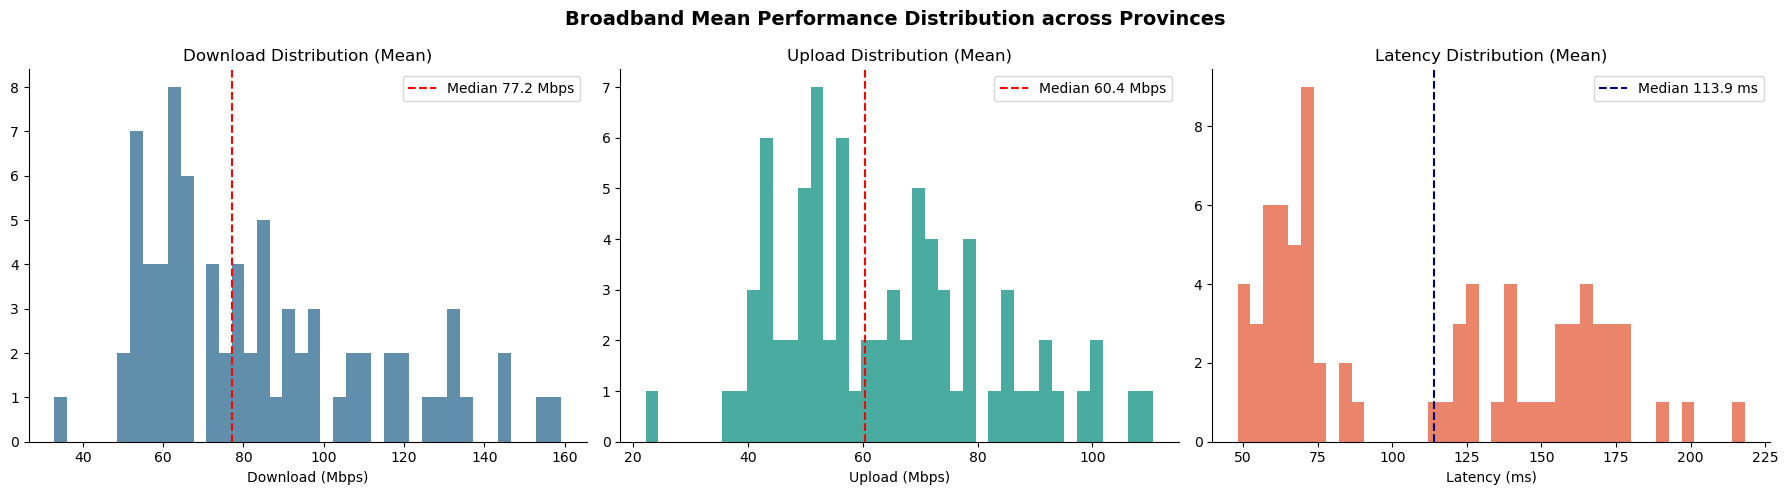

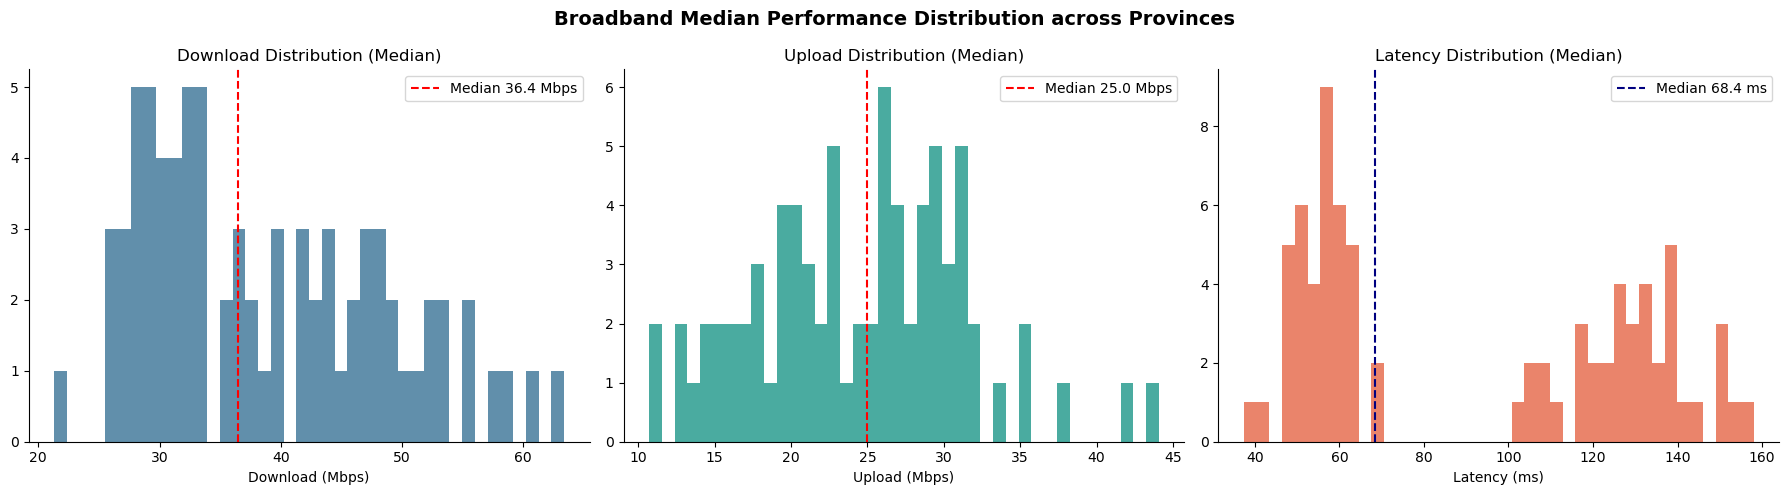

In [ ]:
def plot_distributions(df, net_type):
    sub = df[df["network_type"] == net_type]
    
    for metric_type, dl_col, ul_col, lat_col in [("Mean", "avg_d_mbps", "avg_u_mbps", "avg_lat_ms"),
                                                 ("Median", "med_d_mbps", "med_u_mbps", "med_lat_ms")]:
        fig, axes = plt.subplots(1, 3, figsize=(18, 5))
        
        # DL
        axes[0].hist(sub[dl_col].dropna(), bins=40, color="#457b9d", edgecolor="none", alpha=0.85)
        med_val = sub[dl_col].median()
        axes[0].axvline(med_val, color="red", ls="--", lw=1.5, label=f"Median {med_val:.1f} Mbps")
        axes[0].set_xlabel(f"Download (Mbps)"); axes[0].set_title(f"Download Distribution ({metric_type})"); axes[0].legend()
        
        # UL
        axes[1].hist(sub[ul_col].dropna(), bins=40, color="#2a9d8f", edgecolor="none", alpha=0.85)
        med_ul = sub[ul_col].median()
        axes[1].axvline(med_ul, color="red", ls="--", lw=1.5, label=f"Median {med_ul:.1f} Mbps")
        axes[1].set_xlabel(f"Upload (Mbps)"); axes[1].set_title(f"Upload Distribution ({metric_type})"); axes[1].legend()
        
        # Latency
        axes[2].hist(sub[lat_col].dropna(), bins=40, color="#e76f51", edgecolor="none", alpha=0.85)
        med_lat = sub[lat_col].median()
        axes[2].axvline(med_lat, color="navy", ls="--", lw=1.5, label=f"Median {med_lat:.1f} ms")
        axes[2].set_xlabel("Latency (ms)"); axes[2].set_title(f"Latency Distribution ({metric_type})"); axes[2].legend()
        
        plt.suptitle(f"{net_type.title()} {metric_type} Performance Distribution across Provinces", fontsize=14, fontweight="bold")
        plt.tight_layout()
        plt.show()

plot_distributions(prov_master, "broadband")


## 7 — Province Rankings (Mean vs Median)
*We plot side-by-side Horizontal Bar charts for Download and Upload speeds, colored by region.*


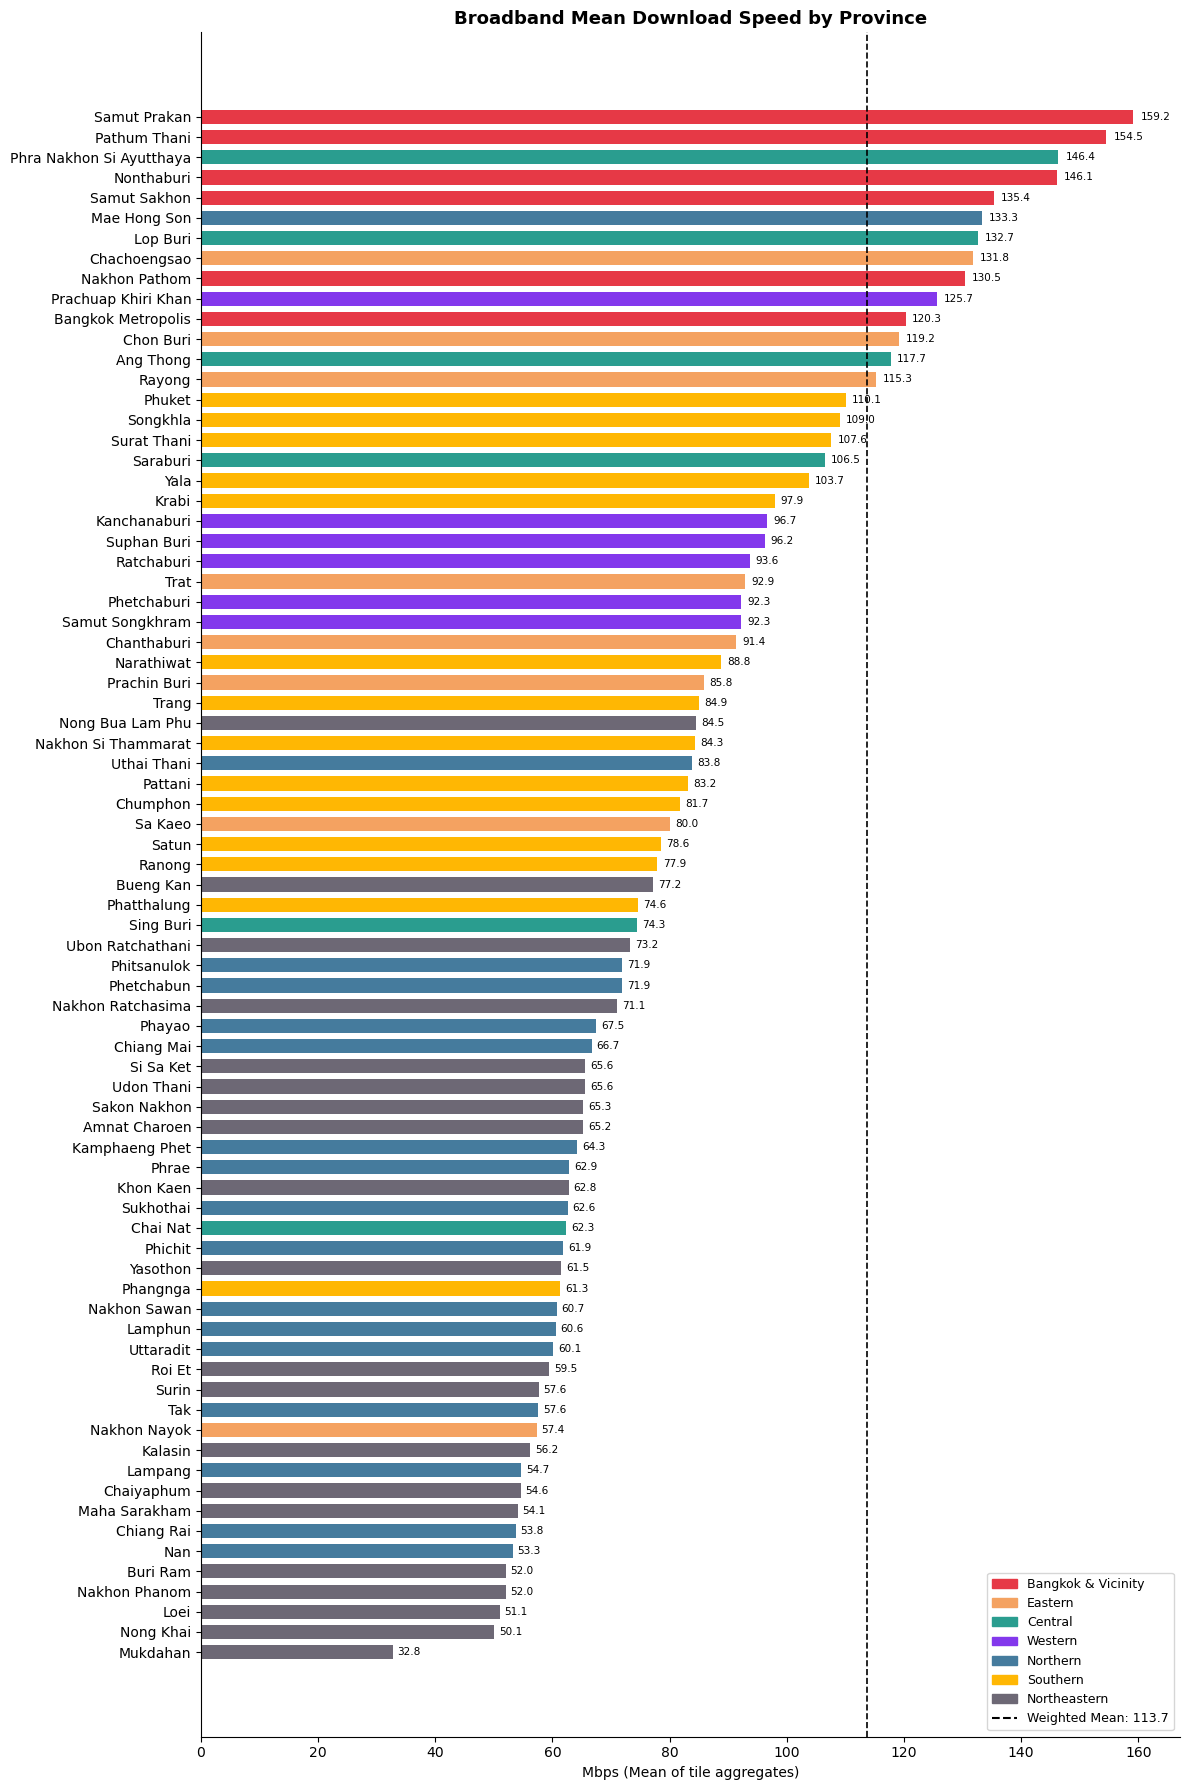

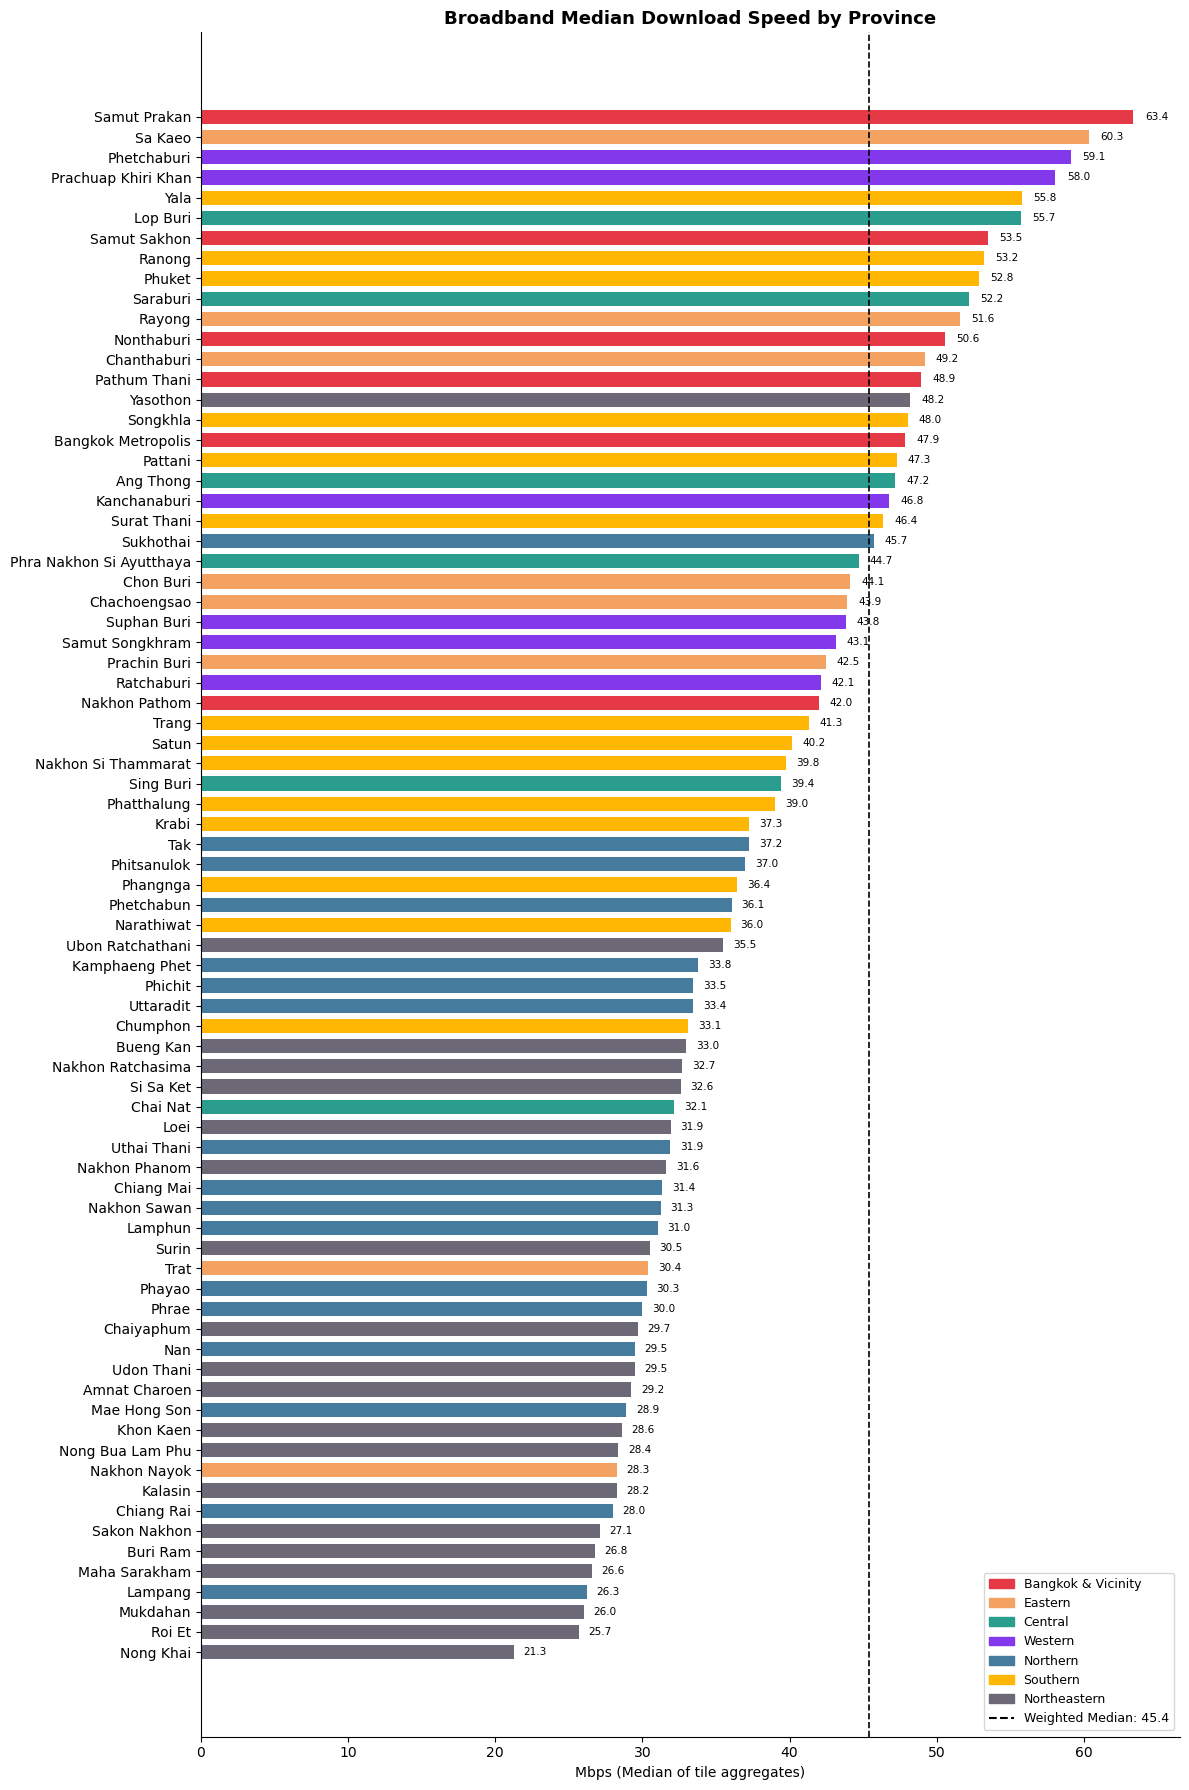

In [ ]:
def plot_rankings(df, net_type, direction="download"):
    sub = df[df["network_type"] == net_type].copy()
    
    if direction == "download":
        mean_col, med_col = "avg_d_mbps", "med_d_mbps"
        title_suffix = "Download Speed"
        unit = "Mbps"
    else:
        mean_col, med_col = "avg_u_mbps", "med_u_mbps"
        title_suffix = "Upload Speed"
        unit = "Mbps"
        
    for col, metric_lbl in [(mean_col, "Mean"), (med_col, "Median")]:
        plot_df = sub[["province", "region", col]].dropna().sort_values(col, ascending=True)
        
        fig, ax = plt.subplots(figsize=(12, 18))
        colors = [REGION_COLORS.get(r, "gray") for r in plot_df["region"]]
        bars = ax.barh(plot_df["province"], plot_df[col], color=colors, edgecolor="none", height=0.7)
        
        # Value labels
        for bar, val in zip(bars, plot_df[col]):
            ax.text(bar.get_width() + (val*0.005 + 0.5), bar.get_y() + bar.get_height()/2,
                    f"{val:.1f}", va="center", fontsize=7.5)
            
        nat_avg = np.average(plot_df[col], weights=sub.loc[plot_df.index, "total_tests"])
        ax.axvline(nat_avg, color="black", ls="--", lw=1.2, label=f"National Weighted {metric_lbl}: {nat_avg:.1f} {unit}")
        
        patches = [mpatches.Patch(color=v, label=k) for k, v in REGION_COLORS.items()]
        ax.legend(handles=patches + [plt.Line2D([0],[0],color="black",ls="--",label=f"Weighted {metric_lbl}: {nat_avg:.1f}")],
                  loc="lower right", fontsize=9)
        ax.set_xlabel(f"{unit} ({metric_lbl} of tile aggregates)")
        ax.set_title(f"{net_type.title()} {metric_lbl} {title_suffix} by Province", fontsize=13, fontweight="bold")
        plt.tight_layout()
        plt.show()

plot_rankings(prov_master, "broadband", "download")


## 8 — Time Series Heatmaps (Province × Quarter)
*Heatmaps of Download speed over time. Show both Mean and Median side-by-side.*

Generating heatmaps (this may take ~30s)...


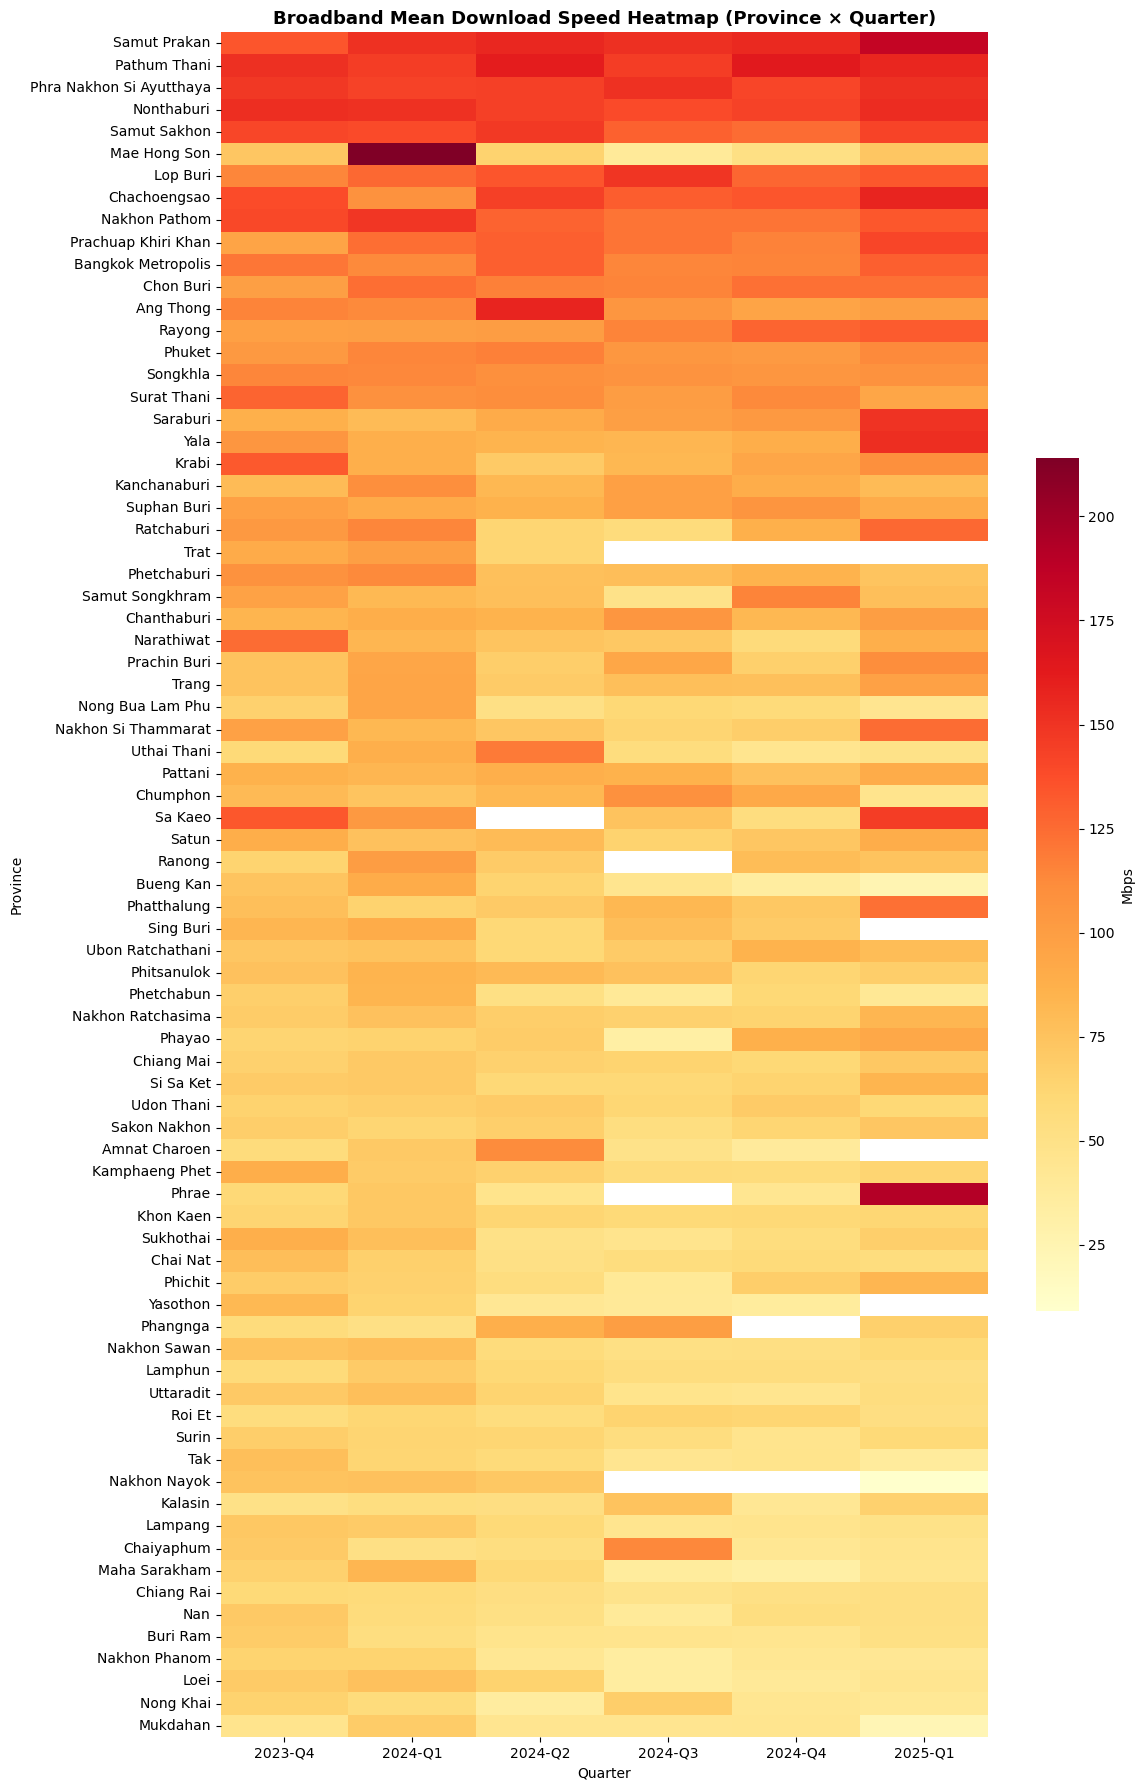

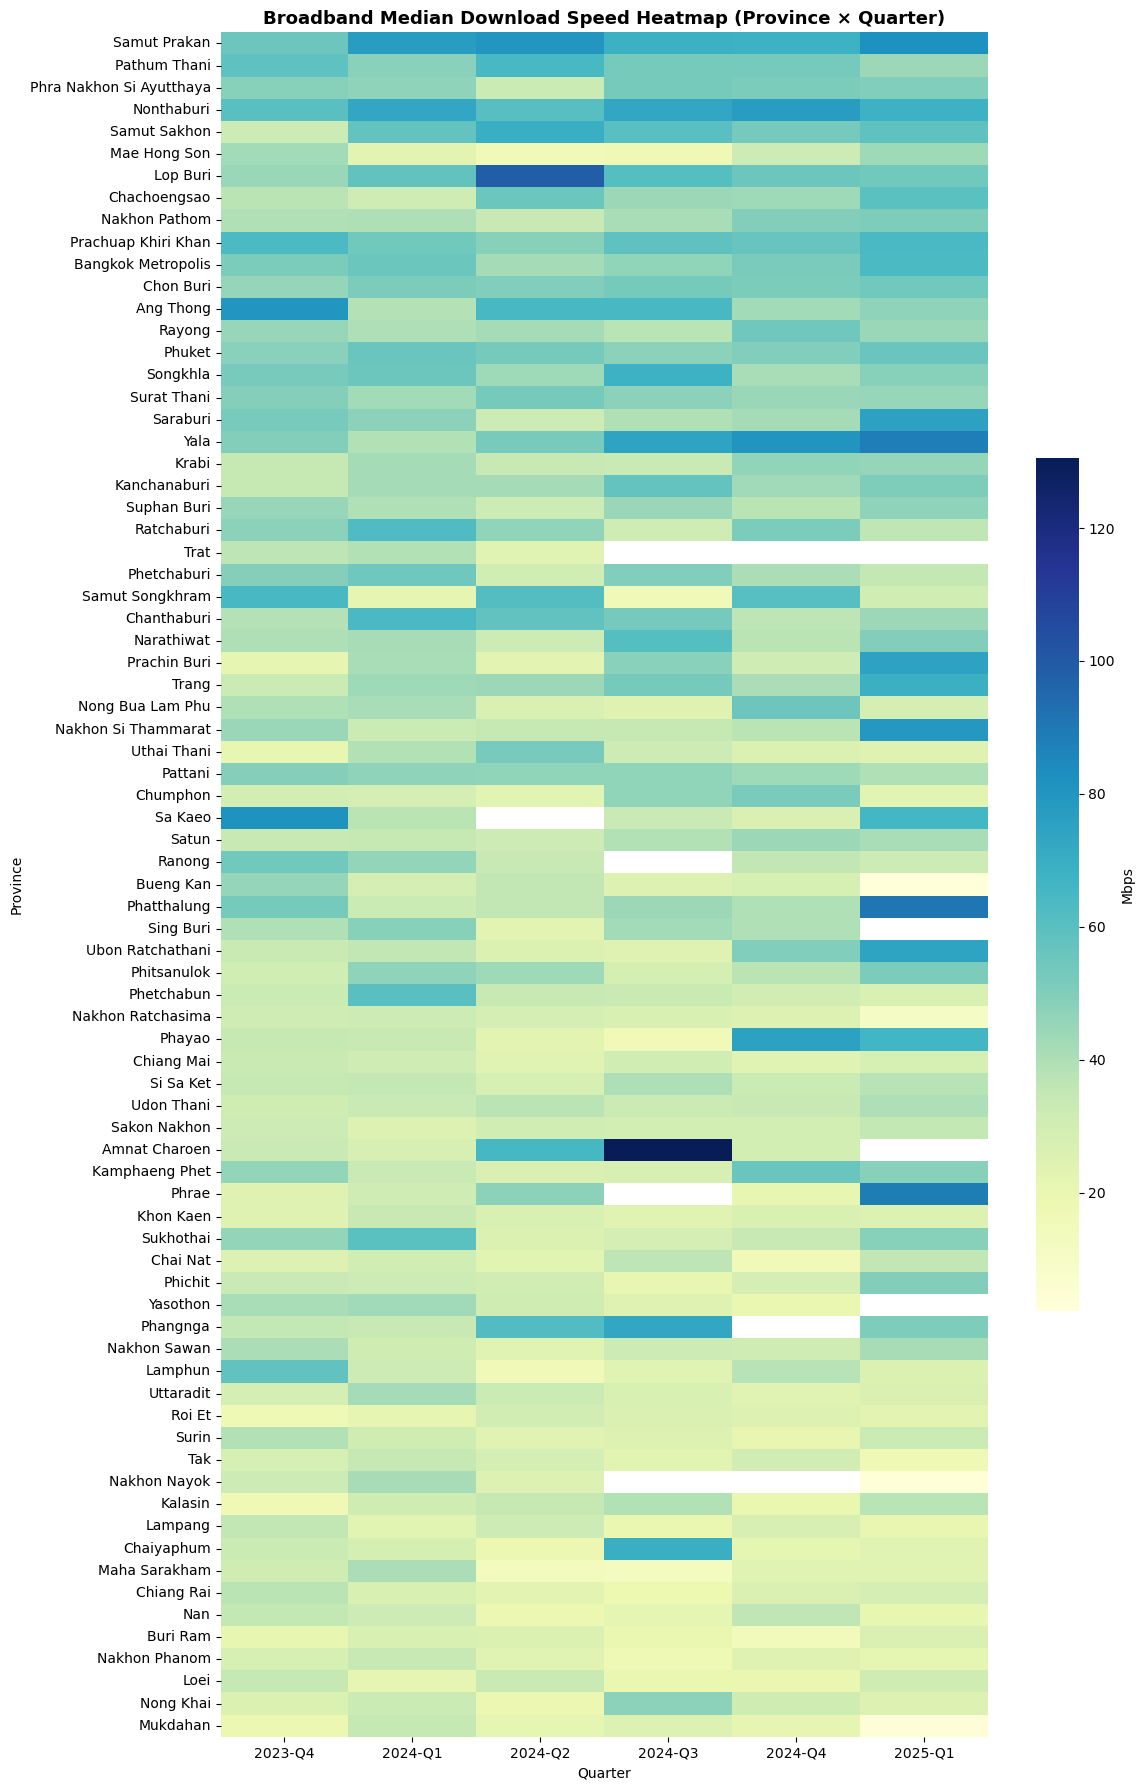

In [ ]:
def plot_heatmaps(df, net_type):
    prov_q = _reaggregate_quarterly(net_type)
    sort_order = df[df["network_type"] == net_type].sort_values("avg_d_mbps", ascending=False)["province"].tolist()

    for metric, col_name, cmap in [("Mean", "avg_d", "YlOrRd"), ("Median", "med_d", "YlGnBu")]:
        pivot = prov_q.pivot(index="province", columns="year_q", values=col_name)
        pivot = pivot.reindex(sort_order).dropna(how="all")

        fig, ax = plt.subplots(figsize=(12, 18))
        sns.heatmap(pivot, cmap=cmap, annot=False, cbar_kws={"label": "Mbps", "shrink": 0.5}, ax=ax)
        ax.set_title(f"{net_type.title()} {metric} Download Speed Heatmap (Province × Quarter)", fontsize=13, fontweight="bold")
        ax.set_xlabel("Quarter"); ax.set_ylabel("Province")
        plt.tight_layout()
        plt.show()

print("Generating heatmaps (this may take ~30s)...")
plot_heatmaps(prov_master, "broadband")


## 9 — Regional Performance Comparison (Boxplots)
*Download, Upload, and Latency boxplots grouped by region. Demonstrates regional speed equity.*


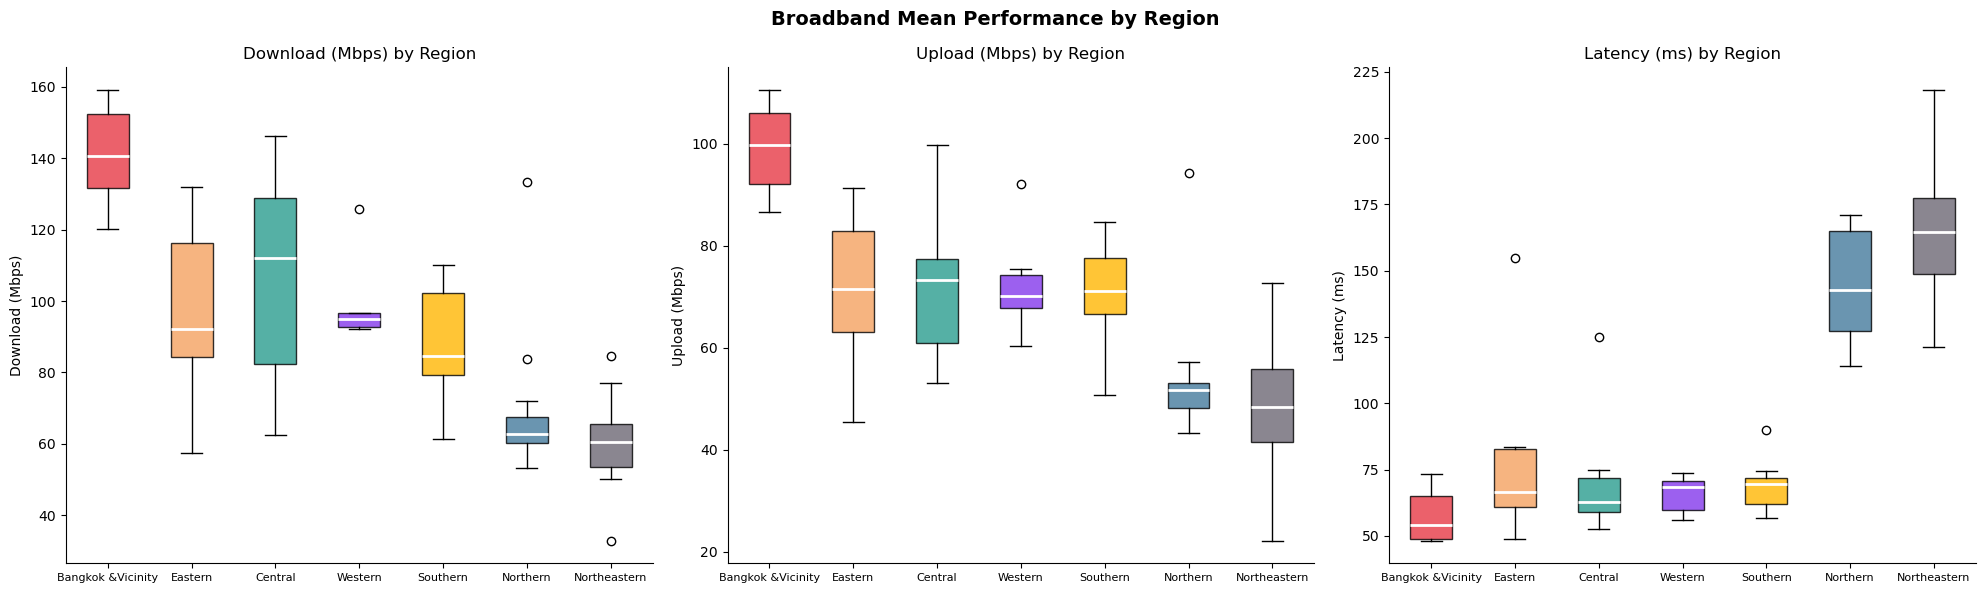

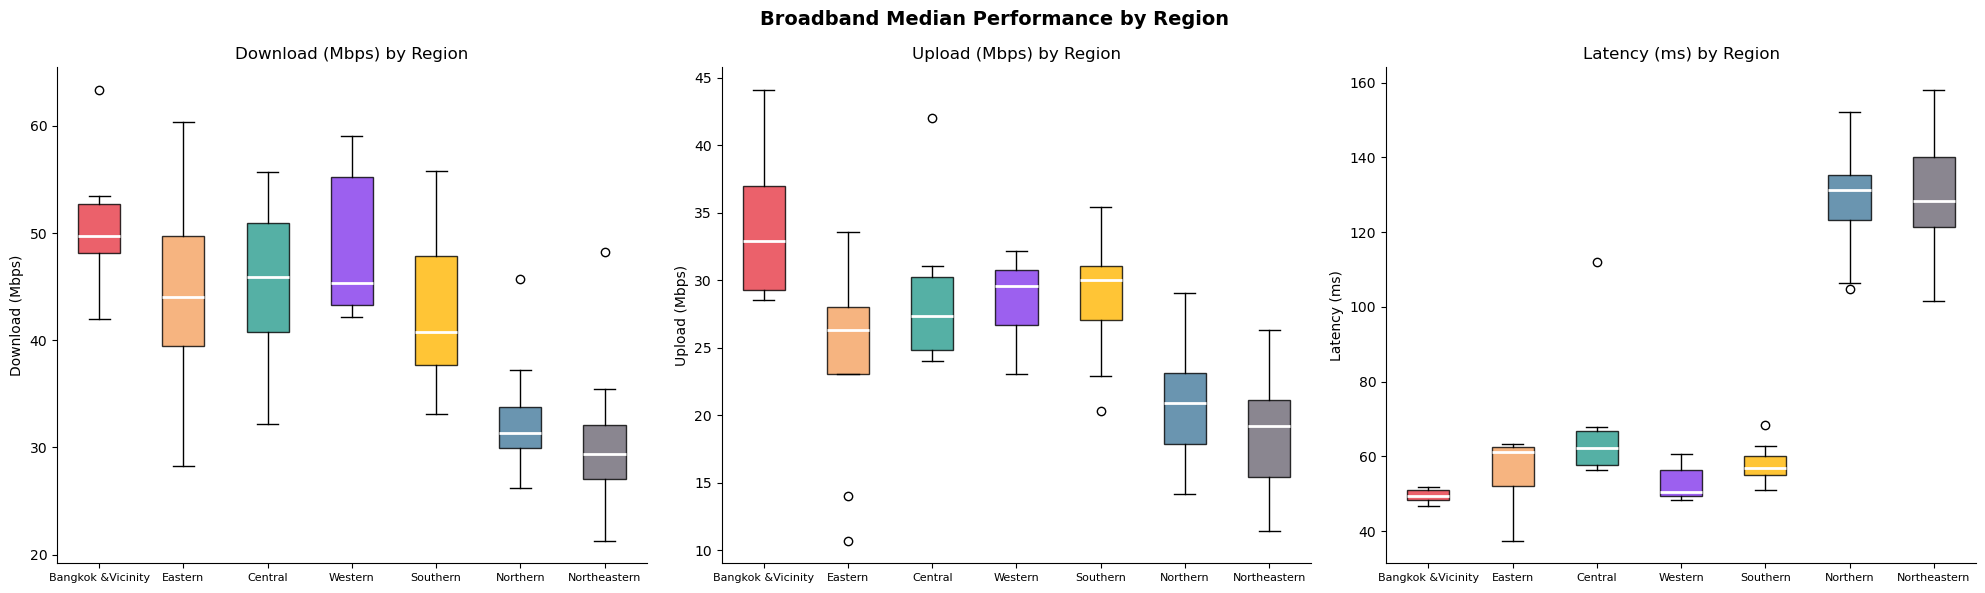

In [ ]:
def plot_boxplots(df, net_type):
    sub = df[df["network_type"] == net_type].dropna(subset=["region"])
    region_order = ['Bangkok & Vicinity', 'Eastern', 'Central', 'Western', 'Southern', 'Northern', 'Northeastern']
    
    for metric_type, dl_col, ul_col, lat_col in [("Mean", "avg_d_mbps", "avg_u_mbps", "avg_lat_ms"),
                                                 ("Median", "med_d_mbps", "med_u_mbps", "med_lat_ms")]:
        fig, axes = plt.subplots(1, 3, figsize=(20, 6))
        
        for ax, metric_col, label_lbl in [(axes[0], dl_col, "Download (Mbps)"),
                                          (axes[1], ul_col, "Upload (Mbps)"),
                                          (axes[2], lat_col, "Latency (ms)")]:
            data = [sub[sub["region"] == r][metric_col].dropna().values for r in region_order]
            bp = ax.boxplot(data, patch_artist=True, notch=False, medianprops=dict(color="white", linewidth=2))
            
            for patch, region in zip(bp["boxes"], region_order):
                patch.set_facecolor(REGION_COLORS[region])
                patch.set_alpha(0.8)
                
            ax.set_xticklabels([r.replace(" & ", " &") for r in region_order], fontsize=8)
            ax.set_ylabel(label_lbl)
            ax.set_title(f"{label_lbl} by Region")
            
        plt.suptitle(f"{net_type.title()} {metric_type} Performance by Region", fontsize=14, fontweight="bold")
        plt.tight_layout()
        plt.show()

plot_boxplots(prov_master, "broadband")


## 10 — Download Speed Trend Lines
*Download trends across quarters for top 5, bottom 5, and provincial hubs.*

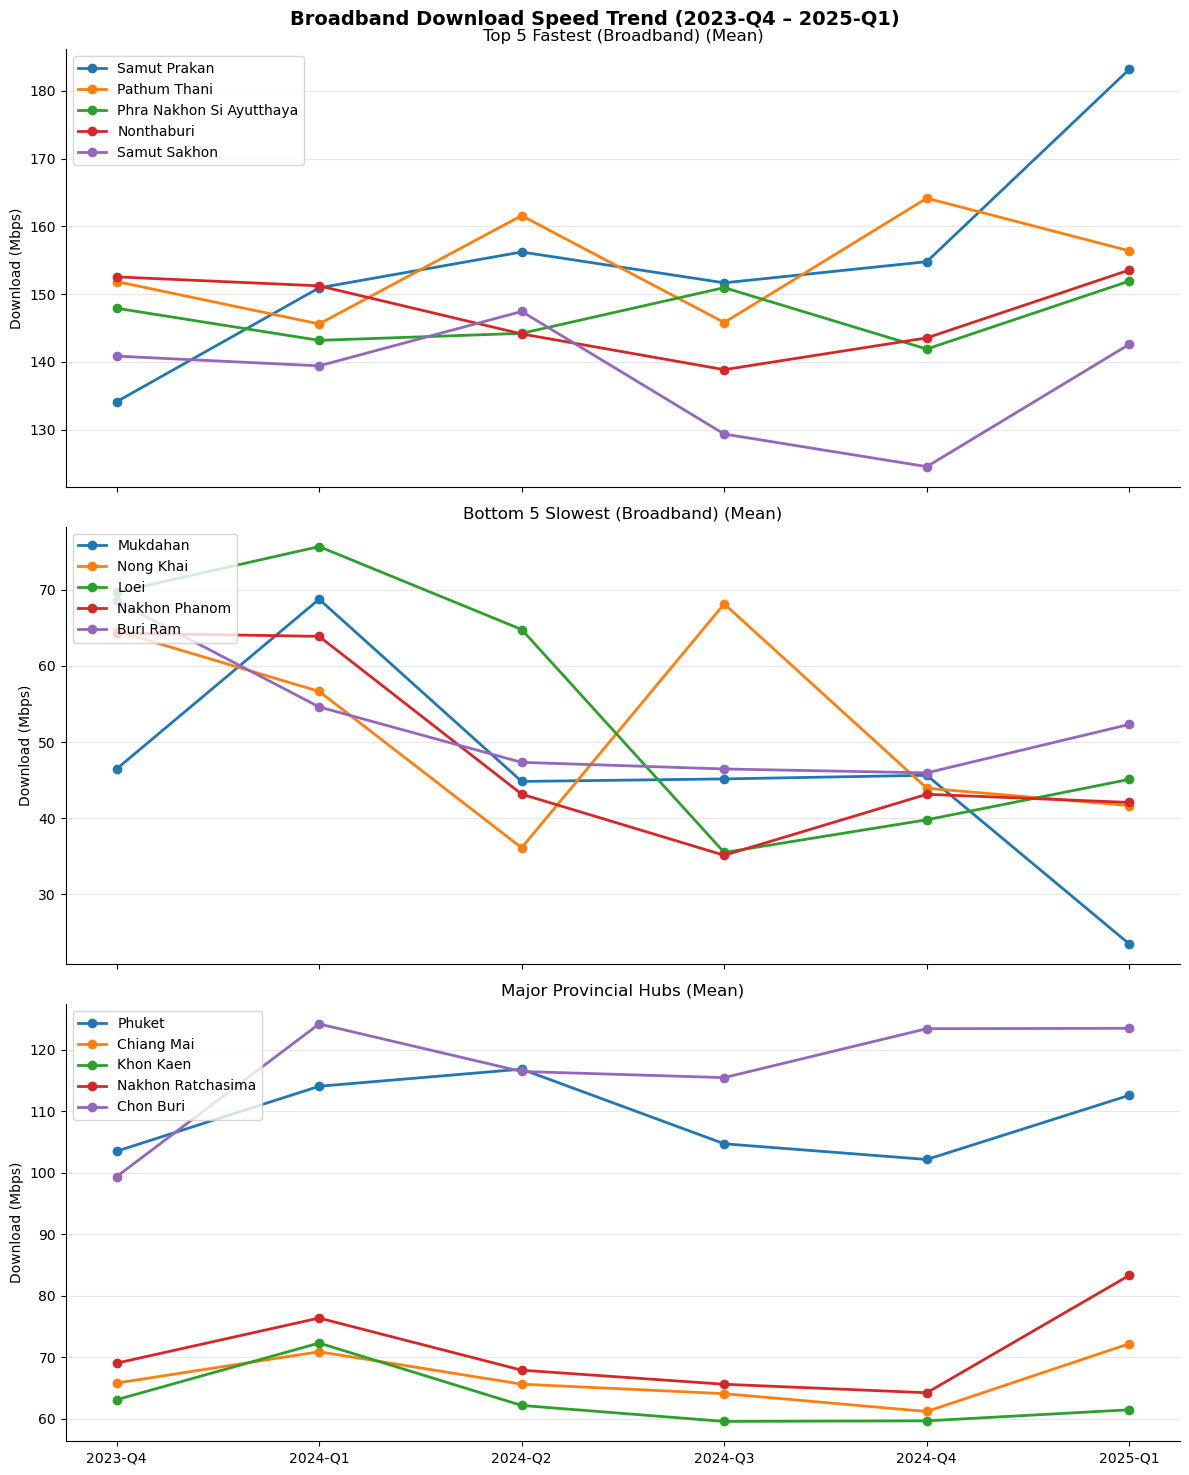

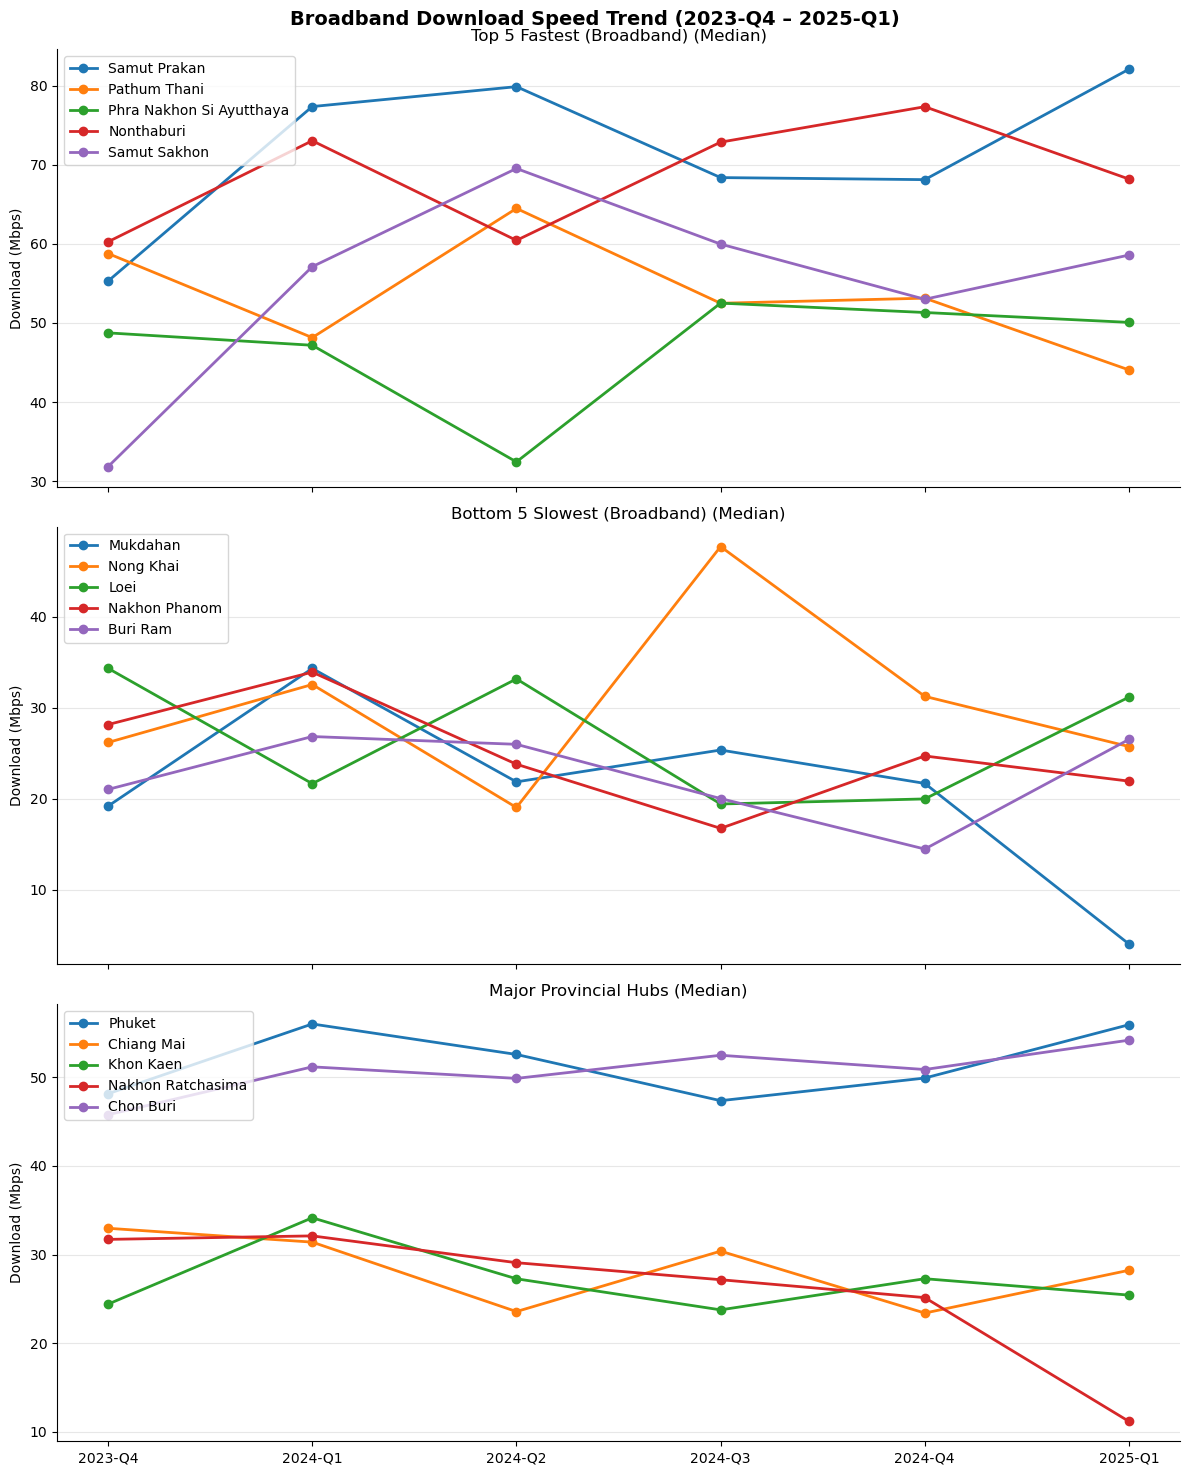

In [ ]:
def plot_trends(df, net_type):
    prov_q = _reaggregate_quarterly(net_type)

    top5 = df[df["network_type"] == net_type].nlargest(5, "avg_d_mbps")["province"].tolist()
    bot5 = df[df["network_type"] == net_type].nsmallest(5, "avg_d_mbps")["province"].tolist()
    first_q = prov_q["year_q"].min()
    last_q  = prov_q["year_q"].max()

    groups = [
        (f"Top 5 Fastest ({net_type.title()})", top5),
        (f"Bottom 5 Slowest ({net_type.title()})", bot5),
        ("Major Provincial Hubs", ["Phuket", "Chiang Mai", "Khon Kaen", "Nakhon Ratchasima", "Chon Buri"]),
    ]

    for metric, col_name in [("Mean", "avg_d"), ("Median", "med_d")]:
        fig, axes = plt.subplots(3, 1, figsize=(12, 15), sharex=True)
        for ax, (title, provinces) in zip(axes, groups):
            for prov in provinces:
                s = prov_q[prov_q["province"] == prov].sort_values("year_q")
                if s.empty: continue
                ax.plot(s["year_q"], s[col_name], marker="o", label=prov, lw=2)
            ax.set_ylabel("Download (Mbps)")
            ax.set_title(f"{title} ({metric})")
            ax.legend(loc="upper left")
            ax.grid(axis="y", alpha=0.3)
        plt.suptitle(f"{net_type.title()} Download Speed Trend ({first_q} – {last_q})", fontsize=14, fontweight="bold")
        plt.tight_layout()
        plt.show()

plot_trends(prov_master, "broadband")


## 11 — GDP & Density vs Speed (OLS Analysis)
*Scatter plots matching Ookla's layout: GDP vs speed on the left, log-density vs speed on the right.*


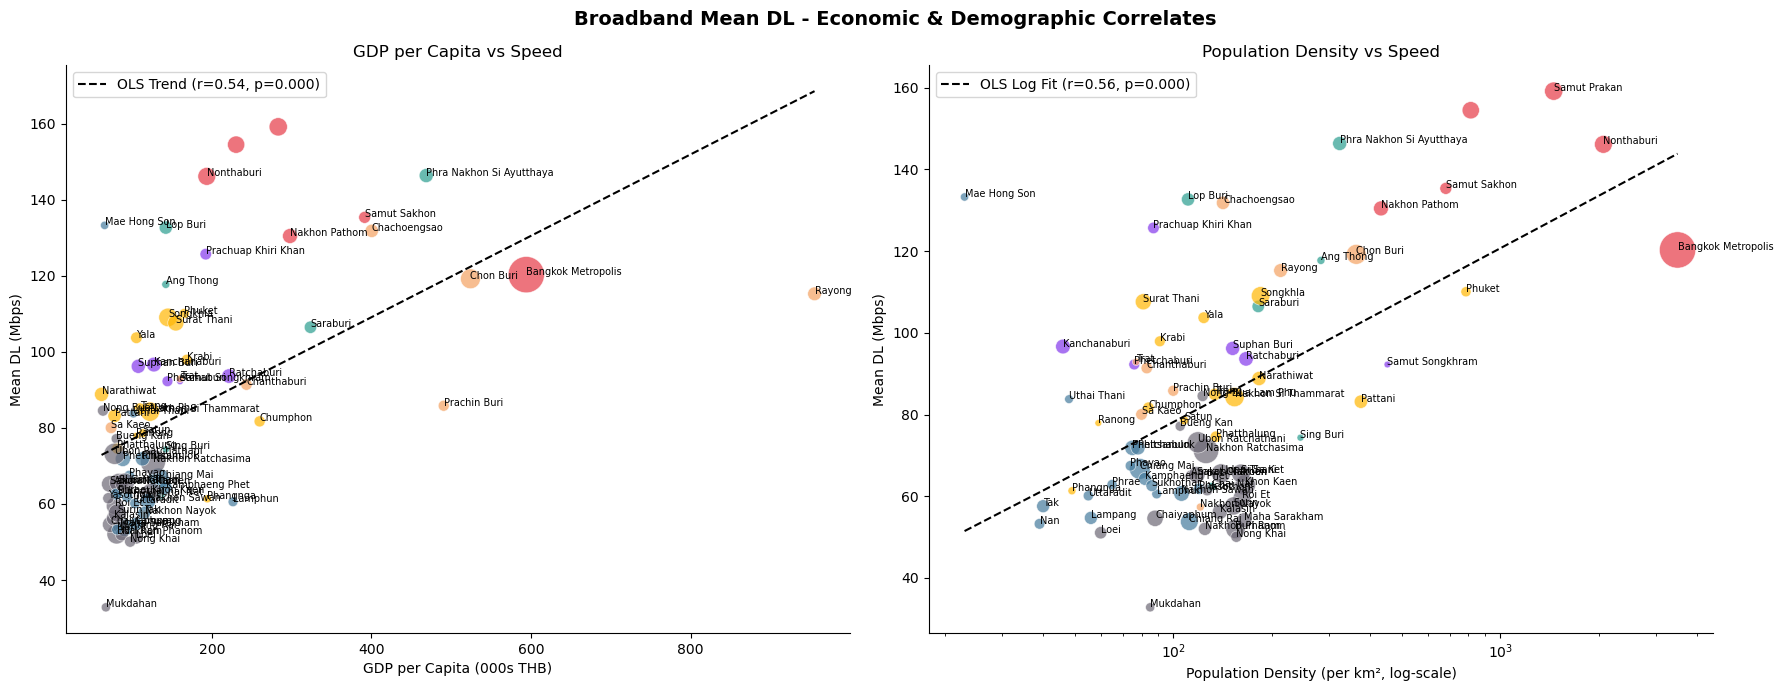

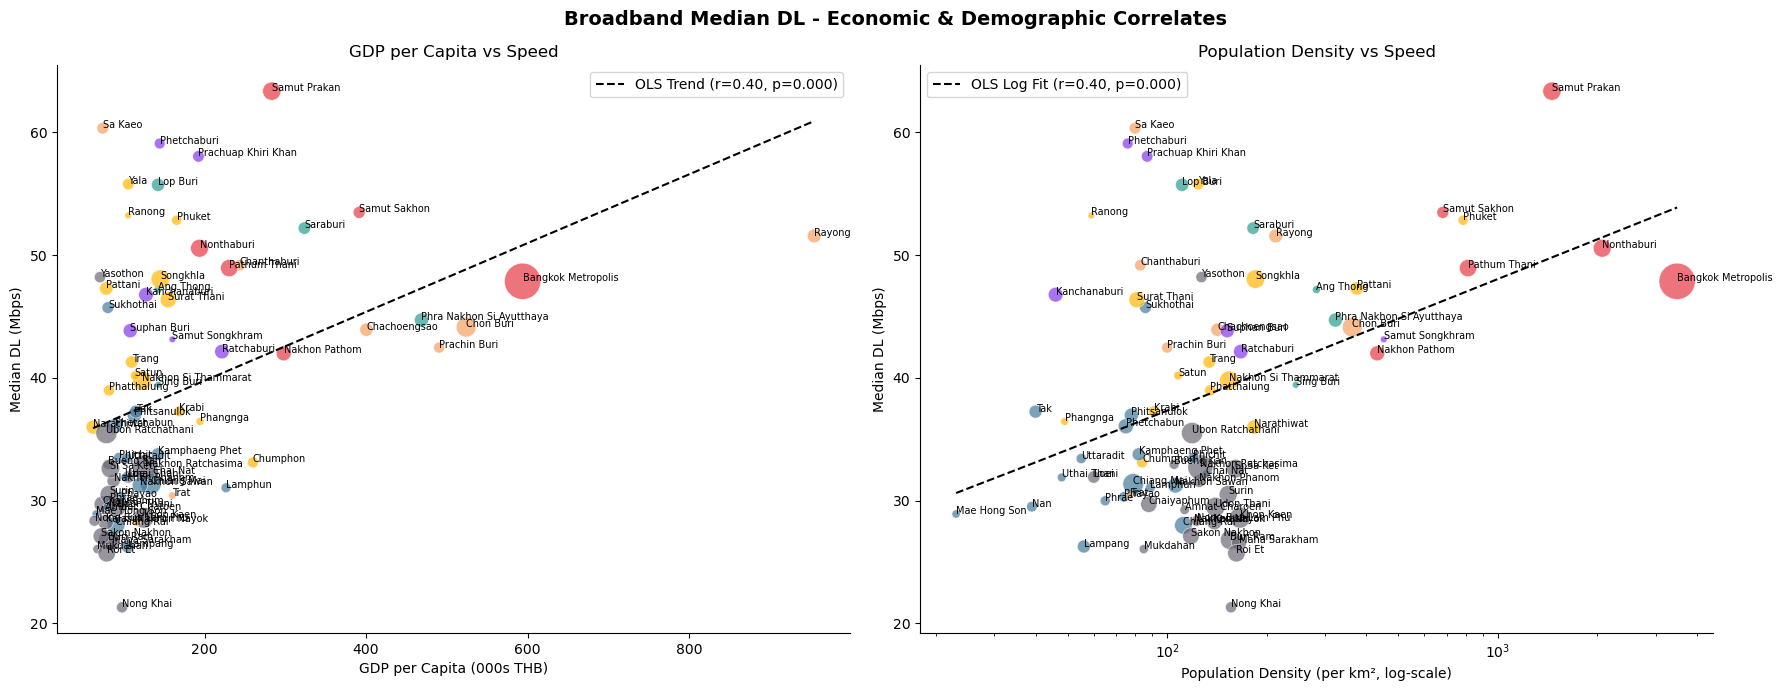

In [ ]:
def plot_scatters(df, net_type):
    sub = df[df["network_type"] == net_type].dropna(subset=["gdp_per_capita_thb_2021", "density_per_km2"])
    
    for metric_type, dl_col in [("Mean", "avg_d_mbps"), ("Median", "med_d_mbps")]:
        fig, axes = plt.subplots(1, 2, figsize=(18, 7))
        
        # ── GDP vs DL ──
        ax = axes[0]
        gdp_val = sub["gdp_per_capita_thb_2021"]
        colors = [REGION_COLORS.get(r, "gray") for r in sub["region"]]
        ax.scatter(gdp_val/1000, sub[dl_col], c=colors, s=sub["pop_2024"]/8000, alpha=0.7, edgecolors="white", lw=0.5)
        
        # OLS
        slope, intercept, r, p, _ = scipy_stats.linregress(gdp_val/1000, sub[dl_col])
        x_fit = np.linspace((gdp_val/1000).min(), (gdp_val/1000).max(), 100)
        ax.plot(x_fit, slope*x_fit + intercept, "k--", label=f"OLS Trend (r={r:.2f}, p={p:.3f})")
        ax.set_xlabel("GDP per Capita (000s THB)")
        ax.set_ylabel(f"{metric_type} DL (Mbps)")
        ax.set_title("GDP per Capita vs Speed")
        ax.legend()
        
        # Annotate outliers
        for _, row in sub.iterrows():
            if row["gdp_per_capita_thb_2021"] > 350000 or row[dl_col] > 280 or row[dl_col] < 150:
                ax.annotate(row["province"], (row["gdp_per_capita_thb_2021"]/1000, row[dl_col]), fontsize=7)
                
        # ── Density vs DL ──
        ax2 = axes[1]
        density_val = sub["density_per_km2"]
        ax2.scatter(density_val, sub[dl_col], c=colors, s=sub["pop_2024"]/8000, alpha=0.7, edgecolors="white", lw=0.5)
        
        # OLS Log
        s_d, i_d, r_d, p_d, _ = scipy_stats.linregress(np.log1p(density_val), sub[dl_col])
        x_fit_d = np.linspace(density_val.min(), density_val.max(), 200)
        ax2.plot(x_fit_d, s_d*np.log1p(x_fit_d) + i_d, "k--", label=f"OLS Log Fit (r={r_d:.2f}, p={p_d:.3f})")
        ax2.set_xlabel("Population Density (per km², log-scale)")
        ax2.set_xscale("log")
        ax2.set_ylabel(f"{metric_type} DL (Mbps)")
        ax2.set_title("Population Density vs Speed")
        ax2.legend()
        
        # Annotate outliers
        for _, row in sub.iterrows():
            if row["density_per_km2"] > 1000 or row[dl_col] > 280 or row[dl_col] < 150:
                ax2.annotate(row["province"], (row["density_per_km2"], row[dl_col]), fontsize=7)
                
        plt.suptitle(f"{net_type.title()} {metric_type} DL - Economic & Demographic Correlates", fontsize=14, fontweight="bold")
        plt.tight_layout()
        plt.show()

plot_scatters(prov_master, "broadband")


## 12 — Upload/Download Ratio (Symmetry Check)
*Bar chart checks if fiber symmetry (ratio ~ 1.0) is present across the country.*


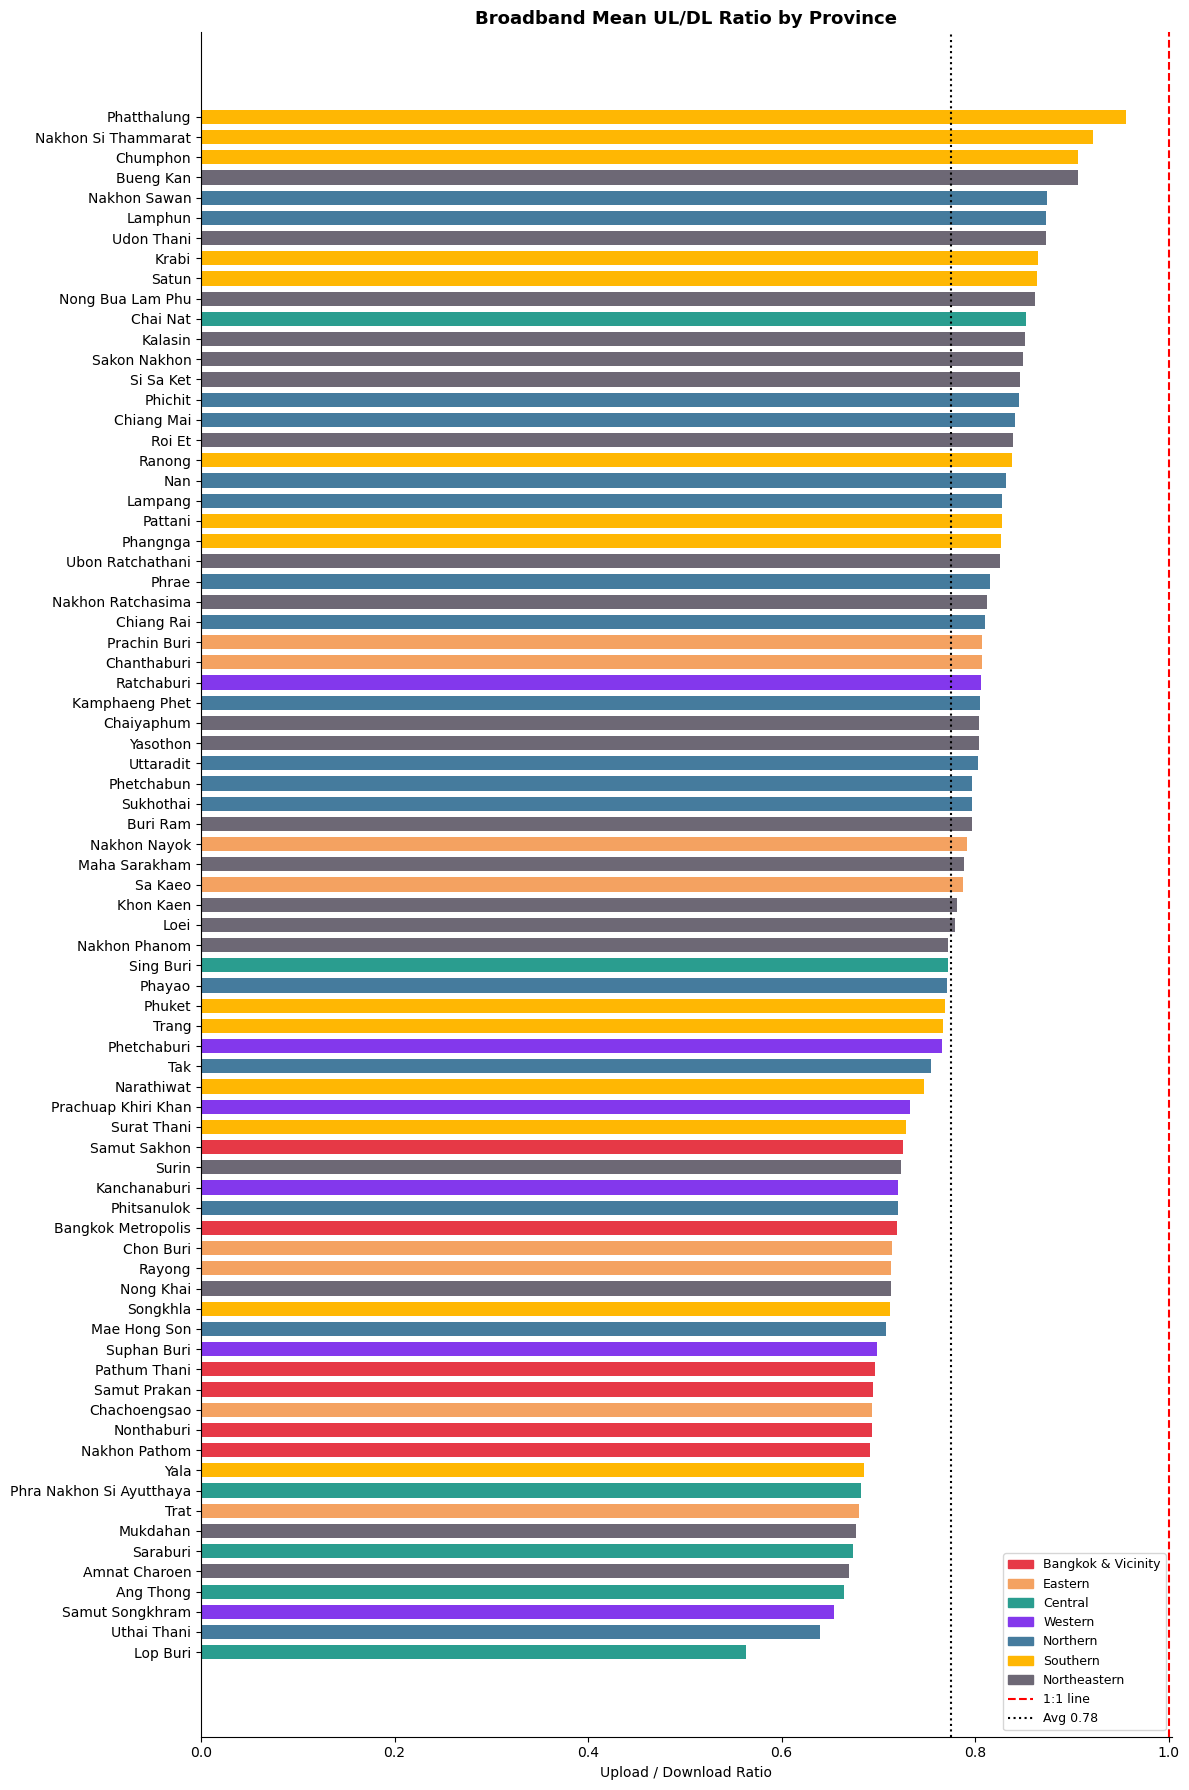

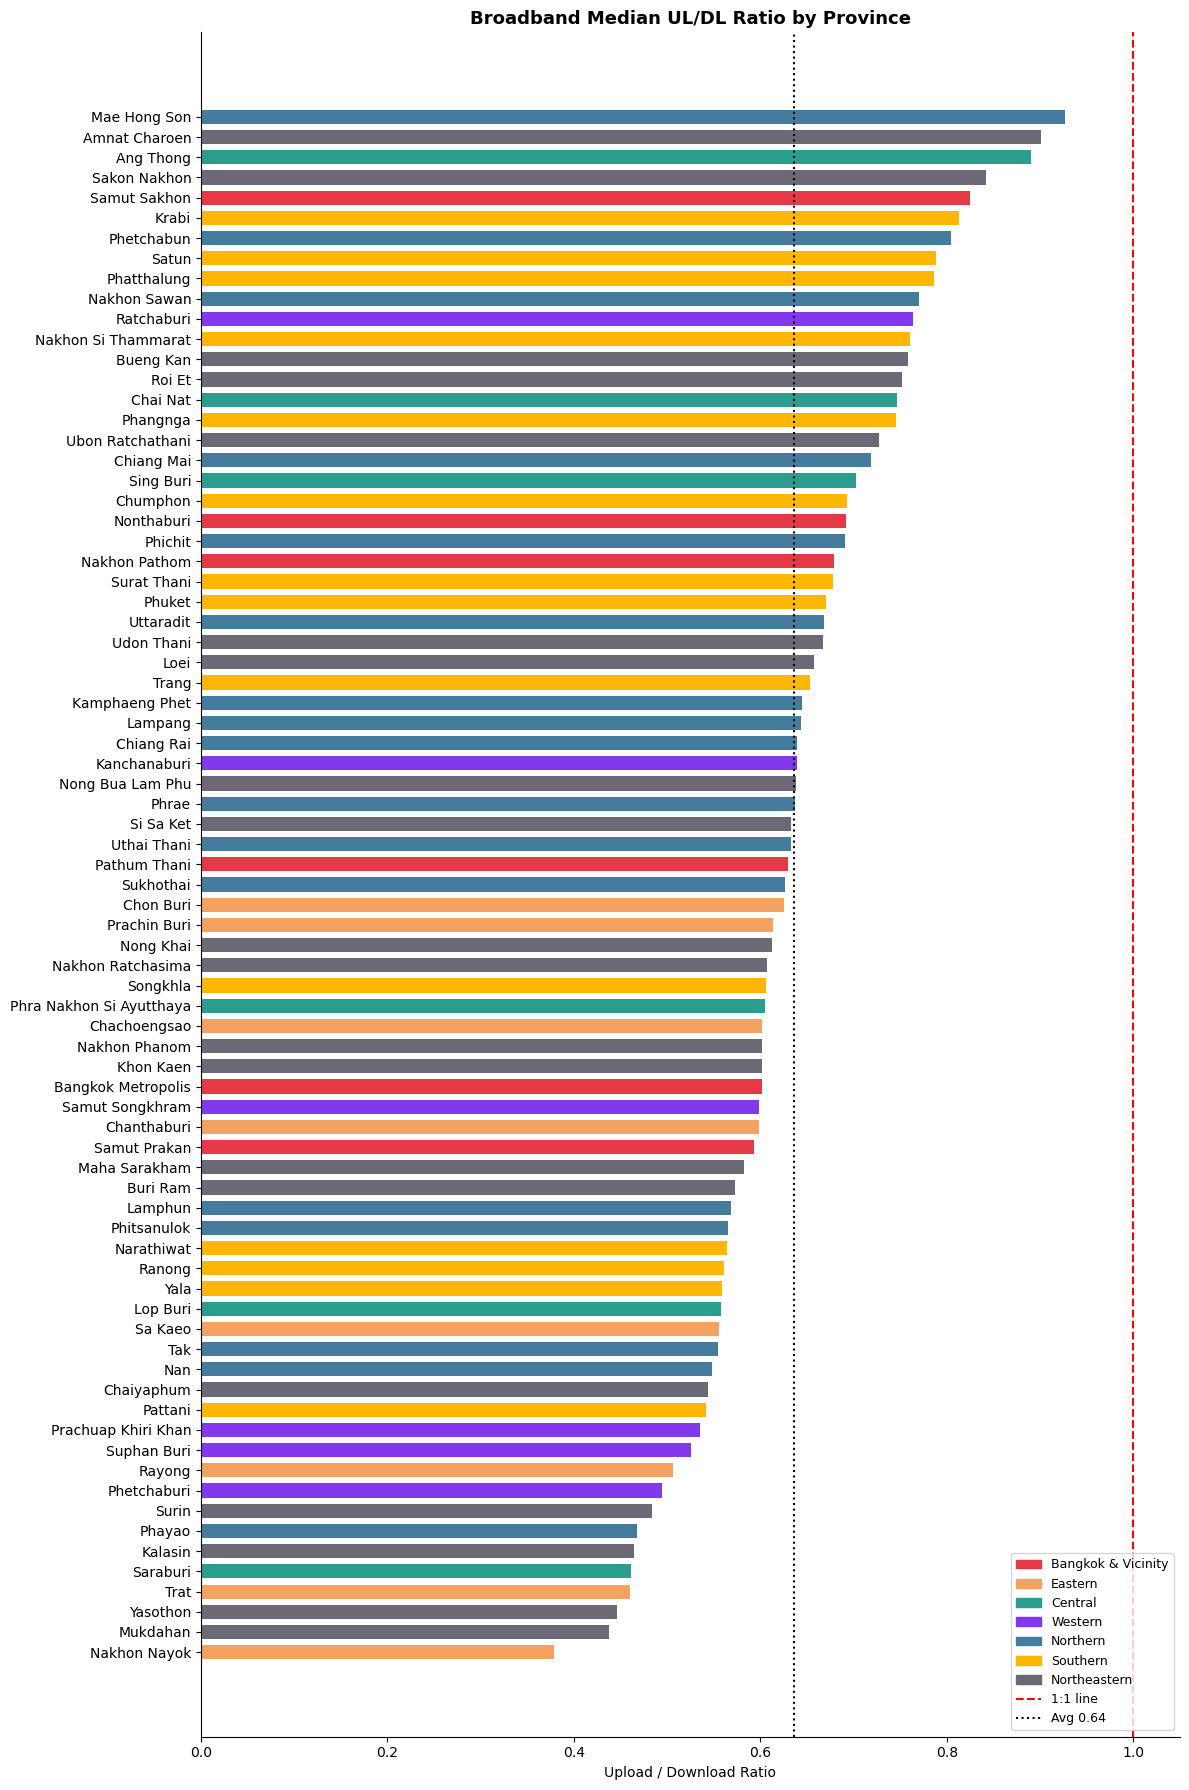

In [ ]:
def plot_ratios(df, net_type):
    sub = df[df["network_type"] == net_type].copy()
    
    for metric_type, ratio_col in [("Mean", "mean_ratio"), ("Median", "med_ratio")]:
        plot_df = sub[["province", "region", ratio_col]].dropna().sort_values(ratio_col, ascending=True)
        
        fig, ax = plt.subplots(figsize=(12, 18))
        colors = [REGION_COLORS.get(r, "gray") for r in plot_df["region"]]
        bars = ax.barh(plot_df["province"], plot_df[ratio_col], color=colors, edgecolor="none", height=0.7)
        
        # Reference lines
        ax.axvline(1.0, color="red", ls="--", label="Symmetric (1:1)")
        nat_ratio = plot_df[ratio_col].mean()
        ax.axvline(nat_ratio, color="black", ls=":", label=f"Average Ratio: {nat_ratio:.2f}")
        
        patches = [mpatches.Patch(color=v, label=k) for k, v in REGION_COLORS.items()]
        ax.legend(handles=patches + [plt.Line2D([0],[0],color="red",ls="--",label="1:1 line"),
                                  plt.Line2D([0],[0],color="black",ls=":",label=f"Avg {nat_ratio:.2f}")],
                  loc="lower right", fontsize=9)
        ax.set_xlabel("Upload / Download Ratio")
        ax.set_title(f"{net_type.title()} {metric_type} UL/DL Ratio by Province", fontsize=13, fontweight="bold")
        plt.tight_layout()
        plt.show()

plot_ratios(prov_master, "broadband")


## 13 — Download Speed Growth
*Percentage speed growth over the first and last quarter of NDT7 data.*

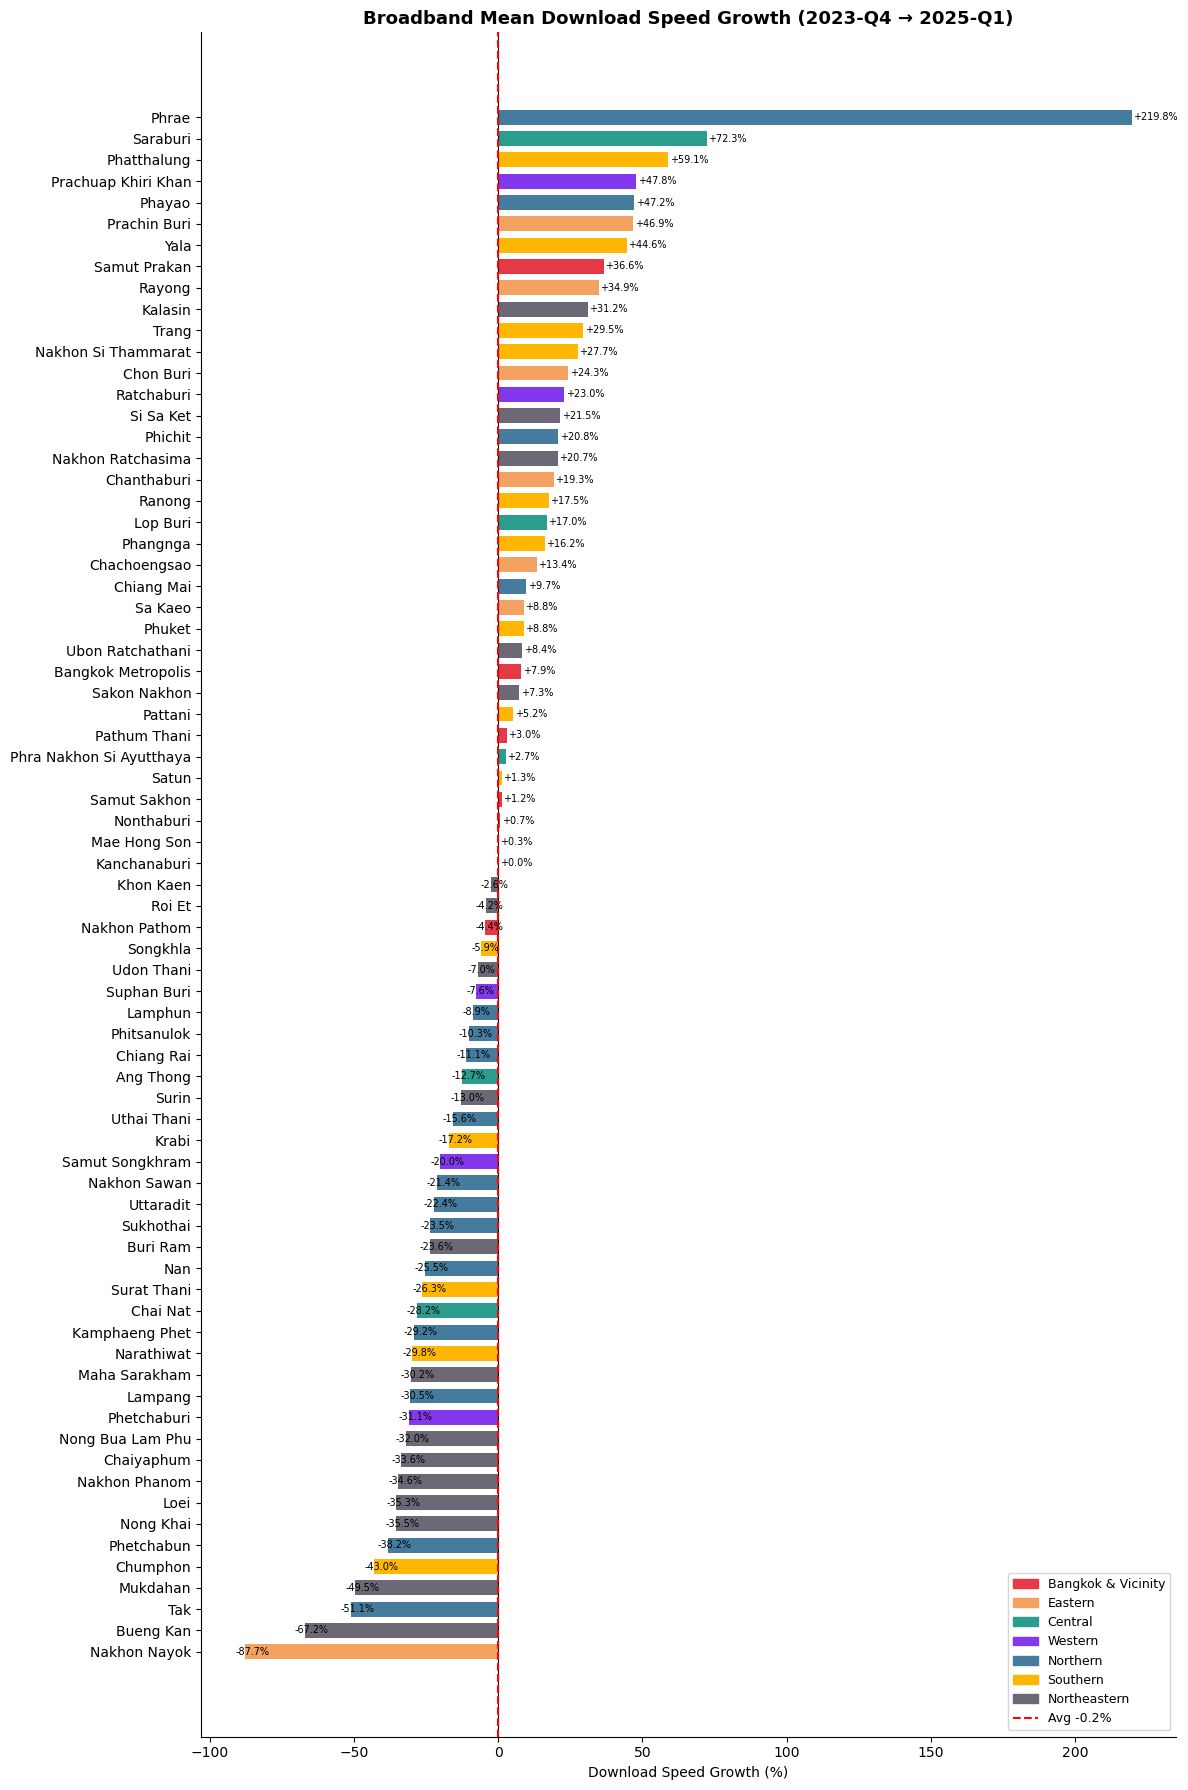

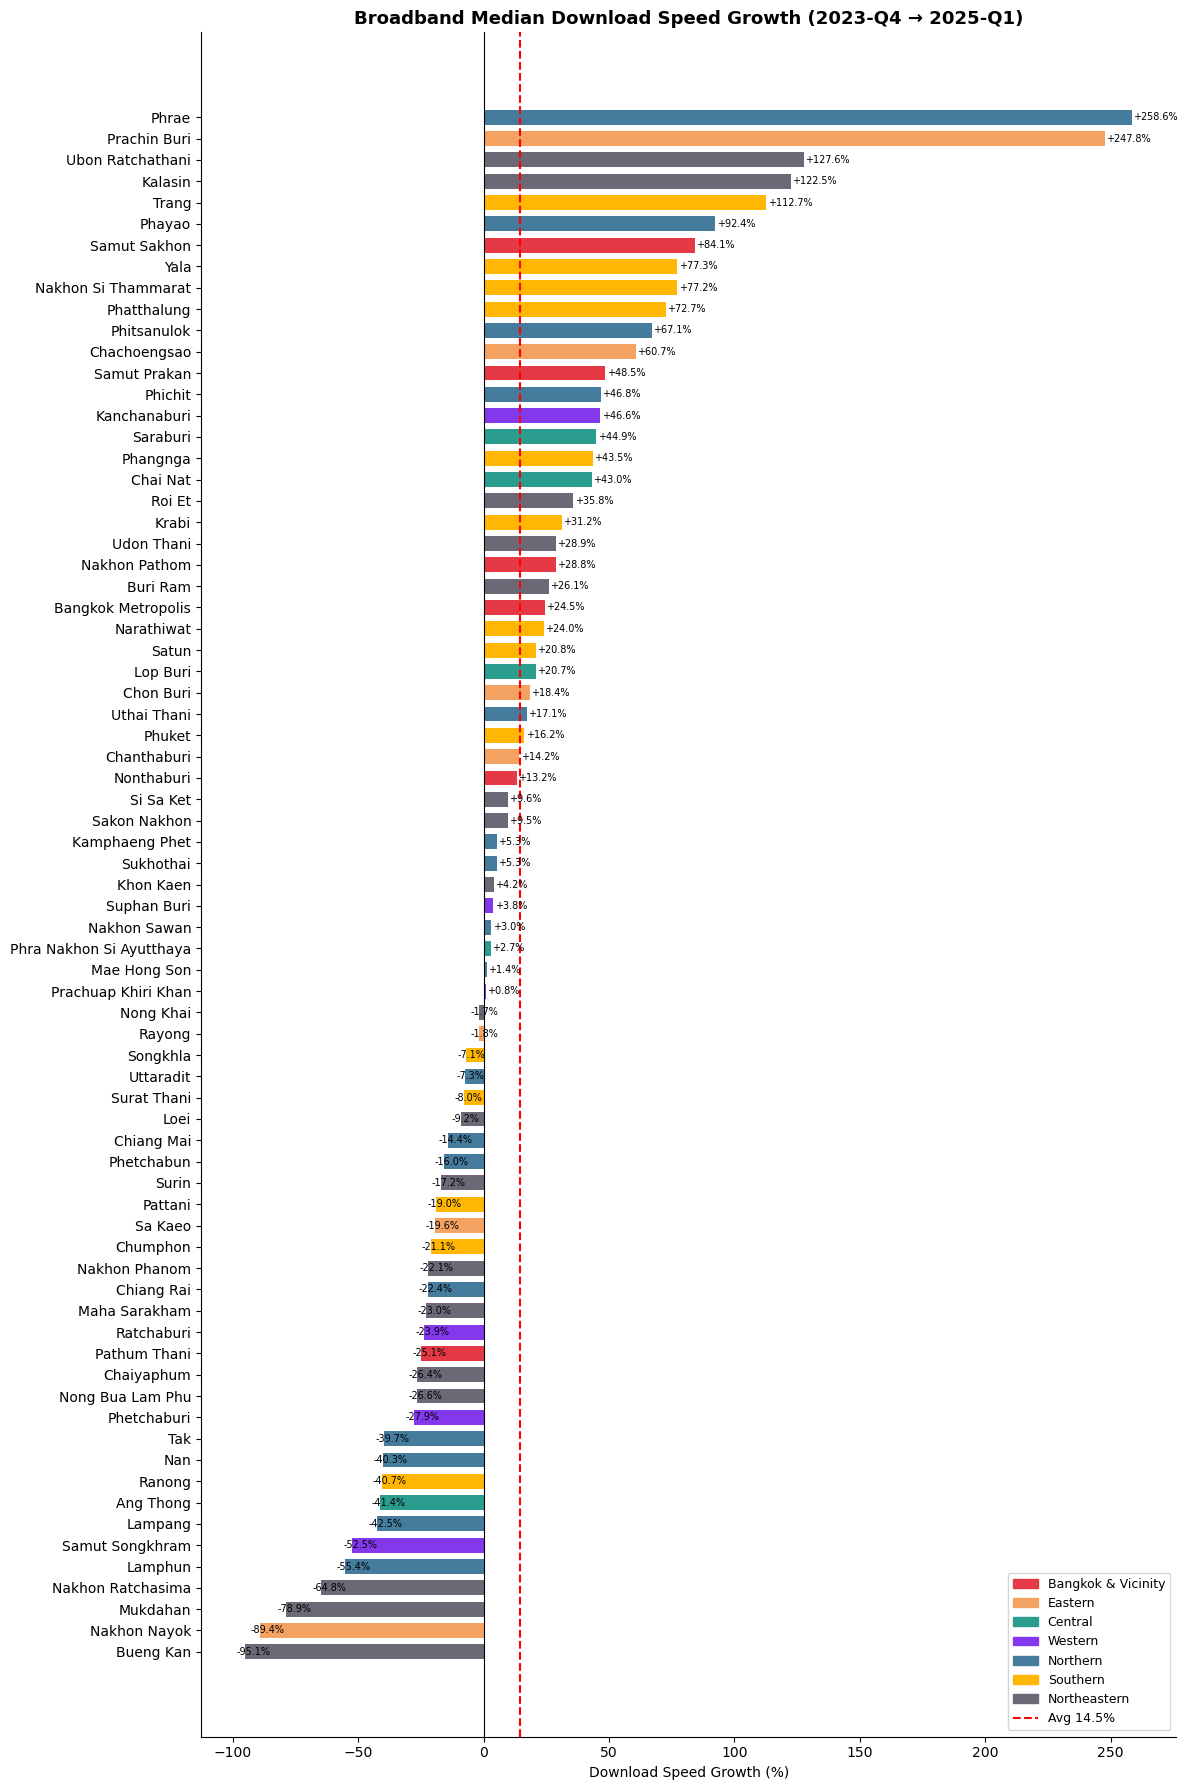

In [ ]:
def plot_growth(df, net_type):
    prov_q = _reaggregate_quarterly(net_type)
    first_q = prov_q["year_q"].min()
    last_q  = prov_q["year_q"].max()

    for metric, col_name in [("Mean", "avg_d"), ("Median", "med_d")]:
        f_vals = prov_q[prov_q["year_q"] == first_q].set_index("province")[col_name]
        l_vals = prov_q[prov_q["year_q"] == last_q].set_index("province")[col_name]

        growth = ((l_vals - f_vals) / f_vals * 100).dropna().sort_values(ascending=True)
        growth_df = growth.reset_index(name="pct_growth")
        growth_df = growth_df.merge(
            df[df["network_type"] == net_type][["province", "region"]], on="province", how="left"
        )

        fig, ax = plt.subplots(figsize=(12, 18))
        colors = [REGION_COLORS.get(r, "gray") for r in growth_df["region"]]
        bars = ax.barh(growth_df["province"], growth_df["pct_growth"], color=colors, edgecolor="none", height=0.7)

        ax.axvline(0, color="black", lw=0.8)
        avg_growth = growth_df["pct_growth"].mean()
        ax.axvline(avg_growth, color="red", ls="--", label=f"Average Growth: {avg_growth:.1f}%")

        for bar, val in zip(bars, growth_df["pct_growth"]):
            ax.text(bar.get_width() + (0.5 if val >= 0 else -3.5), bar.get_y() + bar.get_height()/2,
                    f"{val:+.1f}%", va="center", fontsize=7)

        patches = [mpatches.Patch(color=v, label=k) for k, v in REGION_COLORS.items()]
        ax.legend(
            handles=patches + [plt.Line2D([0],[0], color="red", ls="--", label=f"Avg {avg_growth:.1f}%")],
            loc="lower right", fontsize=9
        )
        ax.set_xlabel("Download Speed Growth (%)")
        ax.set_title(
            f"{net_type.title()} {metric} Download Speed Growth ({first_q} → {last_q})",
            fontsize=13, fontweight="bold"
        )
        plt.tight_layout()
        plt.show()

plot_growth(prov_master, "broadband")


## 14 — Deep Dive Anomalous Provinces
*Quarterly speeds and latency trends for 5 key anomalous provinces.*

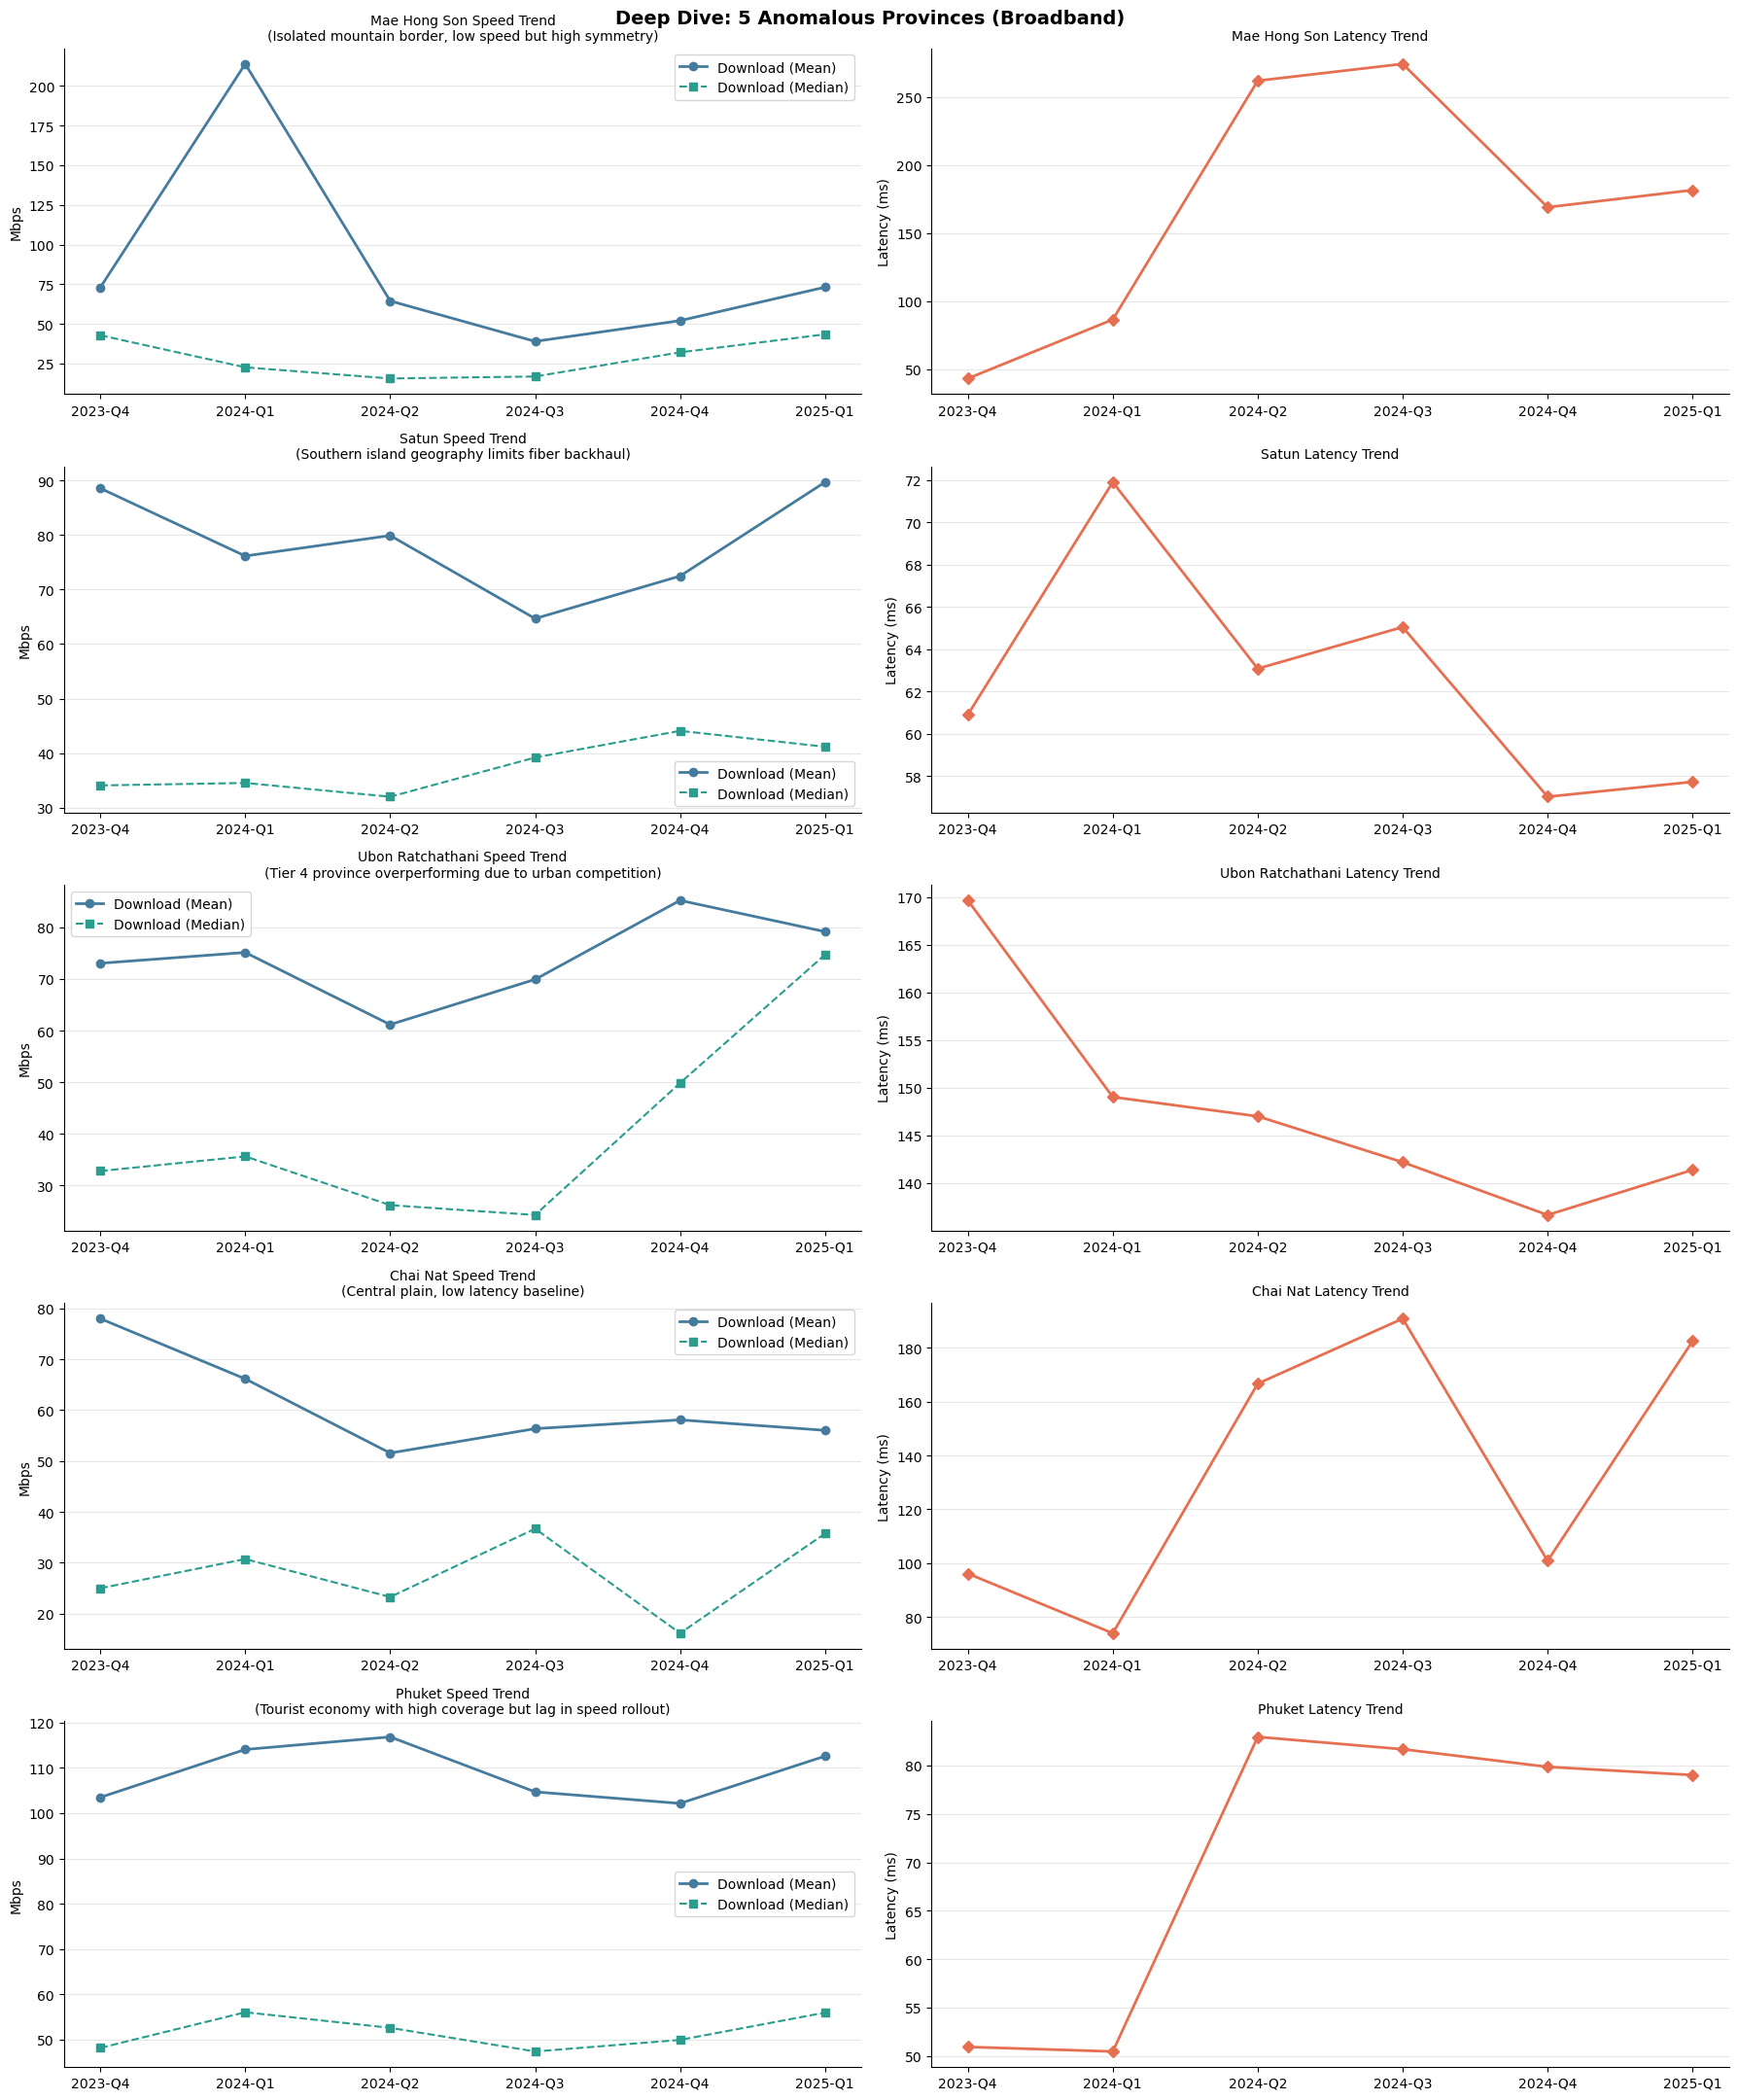

In [ ]:
def plot_deep_dive(df, net_type):
    prov_q = _reaggregate_quarterly(net_type, include_latency=True)

    DIVERGENT_PROVS = {
        "Mae Hong Son":     "Isolated mountain border, low speed but high symmetry",
        "Satun":            "Southern island geography limits fiber backhaul",
        "Ubon Ratchathani": "Tier 4 province overperforming due to urban competition",
        "Chai Nat":         "Central plain, low latency baseline",
        "Phuket":           "Tourist economy with high coverage but lag in speed rollout",
    }

    fig, axes = plt.subplots(len(DIVERGENT_PROVS), 2, figsize=(18, 22))

    for ax_idx, (prov, note) in enumerate(DIVERGENT_PROVS.items()):
        s = prov_q[prov_q["province"] == prov].sort_values("year_q")
        if s.empty:
            continue

        ax_speed = axes[ax_idx, 0]
        ax_speed.plot(s["year_q"], s["avg_d"], "o-", color="#457b9d", label="Download (Mean)", lw=2)
        ax_speed.plot(s["year_q"], s["med_d"], "s--", color="#2a9d8f", label="Download (Median)", lw=1.5)
        ax_speed.set_title(f"{prov} Speed Trend\n({note})", fontsize=10)
        ax_speed.set_ylabel("Mbps")
        ax_speed.legend()
        ax_speed.grid(axis="y", alpha=0.3)

        ax_lat = axes[ax_idx, 1]
        if "avg_lat" in s.columns:
            ax_lat.plot(s["year_q"], s["avg_lat"], "D-", color="#e76f51", lw=2)
        ax_lat.set_title(f"{prov} Latency Trend", fontsize=10)
        ax_lat.set_ylabel("Latency (ms)")
        ax_lat.grid(axis="y", alpha=0.3)

    plt.suptitle(f"Deep Dive: 5 Anomalous Provinces ({net_type.title()})", fontsize=14, fontweight="bold")
    plt.tight_layout()
    plt.show()

plot_deep_dive(prov_master, "broadband")


## 15 — GDP & Density Residuals
*Residual bar charts showing which provinces run faster or slower than their economic/density expectations predict.*


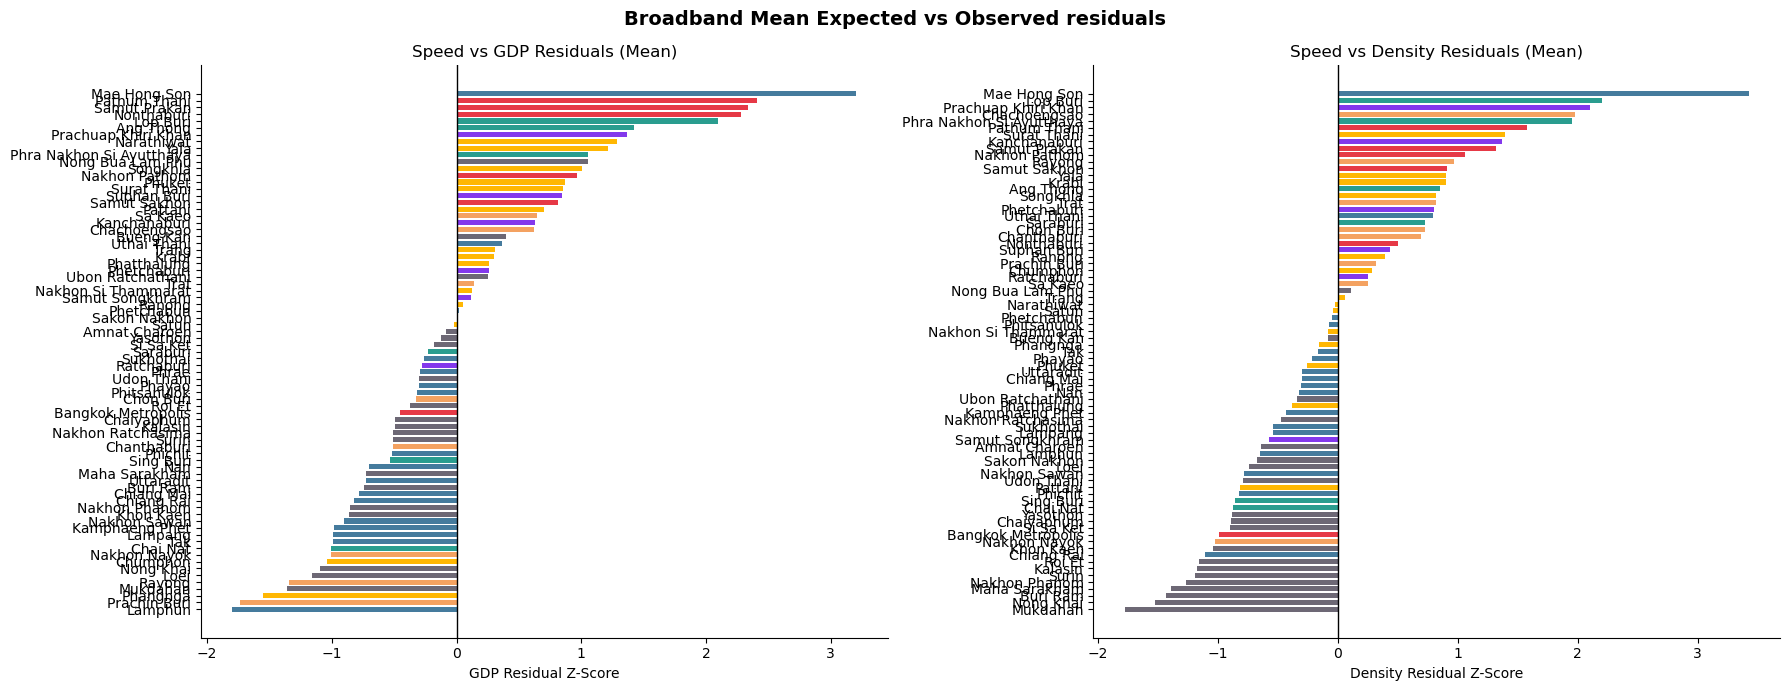

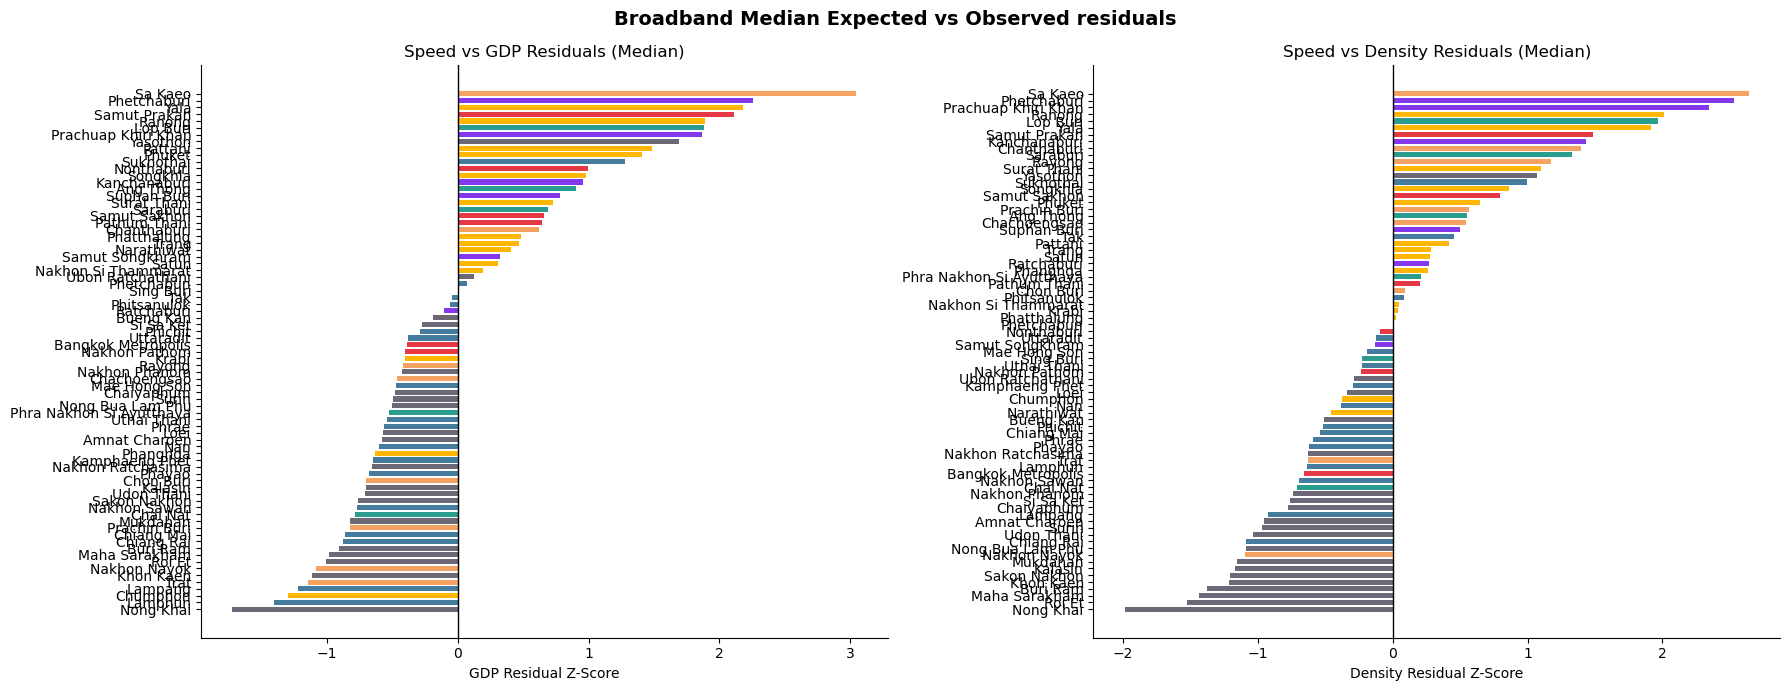

In [ ]:
def plot_residuals(df, net_type):
    sub = df[df["network_type"] == net_type].dropna(subset=["gdp_per_capita_thb_2021", "density_per_km2"]).copy()
    
    for metric_type, dl_col in [("Mean", "avg_d_mbps"), ("Median", "med_d_mbps")]:
        log_gdp = np.log(sub["gdp_per_capita_thb_2021"])
        s_g, i_g, r_g, _, _ = scipy_stats.linregress(log_gdp, sub[dl_col])
        sub["gdp_expected"] = i_g + s_g * log_gdp
        sub["gdp_resid_z"] = scipy_stats.zscore(sub[dl_col] - sub["gdp_expected"])
        
        fig, axes = plt.subplots(1, 2, figsize=(18, 7))
        
        # OLS GDP Residual
        gdp_sort = sub.sort_values("gdp_resid_z")
        colors = [REGION_COLORS.get(r, "gray") for r in gdp_sort["region"]]
        axes[0].barh(gdp_sort["province"], gdp_sort["gdp_resid_z"], color=colors, edgecolor="none", height=0.75)
        axes[0].axvline(0, color="black", lw=1)
        axes[0].set_xlabel("GDP Residual Z-Score")
        axes[0].set_title(f"Speed vs GDP Residuals ({metric_type})")
        
        # Density OLS Residual
        log_den = np.log1p(sub["density_per_km2"])
        s_d, i_d, _, _, _ = scipy_stats.linregress(log_den, sub[dl_col])
        sub["den_expected"] = i_d + s_d * log_den
        sub["den_resid_z"] = scipy_stats.zscore(sub[dl_col] - sub["den_expected"])
        
        den_sort = sub.sort_values("den_resid_z")
        colors_d = [REGION_COLORS.get(r, "gray") for r in den_sort["region"]]
        axes[1].barh(den_sort["province"], den_sort["den_resid_z"], color=colors_d, edgecolor="none", height=0.75)
        axes[1].axvline(0, color="black", lw=1)
        axes[1].set_xlabel("Density Residual Z-Score")
        axes[1].set_title(f"Speed vs Density Residuals ({metric_type})")
        
        plt.suptitle(f"{net_type.title()} {metric_type} Expected vs Observed residuals", fontsize=14, fontweight="bold")
        plt.tight_layout()
        plt.show()

plot_residuals(prov_master, "broadband")


## 16 — Coverage (Tests per 1,000 Population)
*A measure of broadband penetration and app adoption across provinces.*


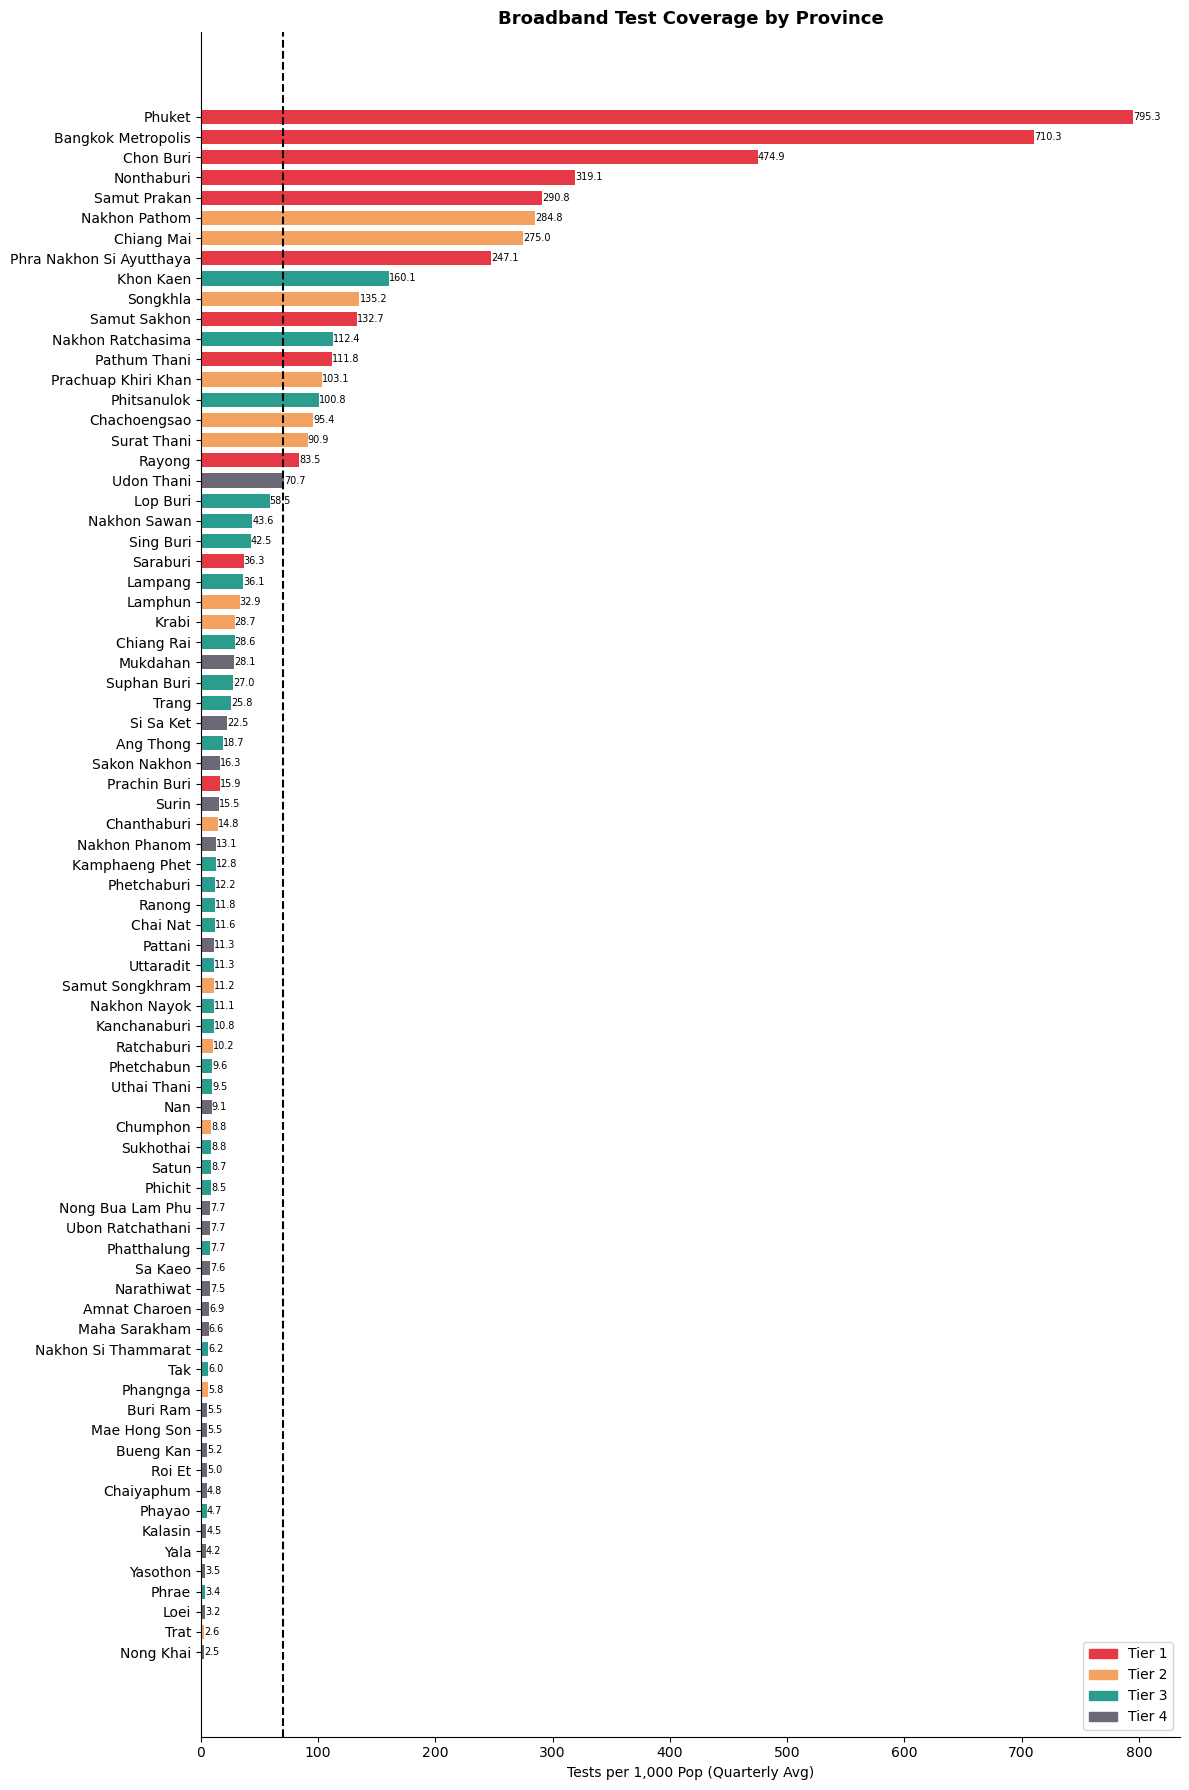

In [ ]:
def plot_coverage(df, net_type):
    sub = df[df["network_type"] == net_type].copy()
    cov = sub.sort_values("tests_per_1000_pop")
    
    tier_pal = {1: "#e63946", 2: "#f4a261", 3: "#2a9d8f", 4: "#6d6875"}
    colors = [tier_pal.get(int(t), "gray") for t in cov["internet_tier"]]
    
    fig, ax = plt.subplots(figsize=(12, 18))
    bars = ax.barh(cov["province"], cov["tests_per_1000_pop"], color=colors, edgecolor="none", height=0.7)
    ax.axvline(sub["tests_per_1000_pop"].mean(), color="black", ls="--", label="National Mean")
    
    for bar, val in zip(bars, cov["tests_per_1000_pop"]):
        ax.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2, f"{val:.1f}", va="center", fontsize=7)
        
    patches = [mpatches.Patch(color=v, label=f"Tier {k}") for k, v in tier_pal.items()]
    ax.legend(handles=patches, loc="lower right")
    ax.set_xlabel("Tests per 1,000 Pop (Quarterly Avg)")
    ax.set_title(f"{net_type.title()} Test Coverage by Province", fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.show()

plot_coverage(prov_master, "broadband")


## 17 — Anomaly Detection & Flags
*Rule-based flagging to find structural anomalies, low coverage, or latency spikes.*


In [ ]:
def run_flags(df, net_type):
    sub = df[df["network_type"] == net_type].copy()
    
    # Calculate expected columns
    tier_med = sub.groupby("internet_tier")["avg_d_mbps"].median()
    sub["tier_expected"] = sub["internet_tier"].map(tier_med)
    
    national_std = sub["avg_d_mbps"].std()
    tier_expected_speed = sub.groupby("internet_tier")["avg_d_mbps"].median()
    
    flags = {}
    
    # A. Low Coverage
    for _, row in sub[sub["total_tests"] < 200].iterrows():
        flags.setdefault(row["province"], []).append(f"LOW_COVERAGE ({row['total_tests']:.0f} tests)")
        
    # B. Tier Mismatch
    for _, row in sub.iterrows():
        tier = row["internet_tier"]
        if pd.isna(tier): continue
        if tier == 1 and row["avg_d_mbps"] < tier_expected_speed.get(3, 0):
            flags.setdefault(row["province"], []).append(f"TIER1_UNDERPERFORM ({row['avg_d_mbps']:.0f} Mbps)")
        if tier == 4 and row["avg_d_mbps"] > tier_expected_speed.get(2, 999) + 0.5*national_std:
            flags.setdefault(row["province"], []).append(f"TIER4_OVERPERFORM ({row['avg_d_mbps']:.0f} Mbps)")
            
    # C. Ratio Outliers
    ratio_z = scipy_stats.zscore(sub["mean_ratio"].fillna(sub["mean_ratio"].median()))
    for (idx, row), z in zip(sub.iterrows(), ratio_z):
        if z > 2.0: flags.setdefault(row["province"], []).append(f"HIGH_UL_DL_RATIO (z={z:.1f})")
        if z < -2.0: flags.setdefault(row["province"], []).append(f"LOW_UL_DL_RATIO (z={z:.1f})")
        
    # D. Latency
    for _, row in sub.iterrows():
        if row["avg_lat_ms"] < 6:
            flags.setdefault(row["province"], []).append(f"ULTRA_LOW_LATENCY ({row['avg_lat_ms']:.1f} ms)")
            
    # E. Regional outliers
    for reg, grp in sub.groupby("region"):
        if len(grp) < 4: continue
        rz = scipy_stats.zscore(grp["avg_d_mbps"].fillna(grp["avg_d_mbps"].median()))
        for idx, zval in zip(grp.index, rz):
            if abs(zval) > 2.5:
                name = grp.loc[idx, "province"]
                flags.setdefault(name, []).append(f"REGIONAL_OUTLIER (z={zval:.1f} in {reg})")
                
    print(f"=== {net_type.upper()} FLAGGED PROVINCES ({len(flags)}/77) ===")
    for name in sorted(flags.keys(), key=lambda x: -len(flags[x])):
        print(f"** {name} | {len(flags[name])} flags **")
        for f in flags[name]:
            print(f"   • {f}")
        print()
    return flags

bb_flags = run_flags(prov_master, "broadband")


=== BROADBAND FLAGGED PROVINCES (4/77) ===
** Mae Hong Son | 2 flags **
   • TIER4_OVERPERFORM (133 Mbps)
   • REGIONAL_OUTLIER (z=3.7 in Northern)

** Lop Buri | 1 flags **
   • LOW_UL_DL_RATIO (z=-2.8)

** Phatthalung | 1 flags **
   • HIGH_UL_DL_RATIO (z=2.4)

** Mukdahan | 1 flags **
   • REGIONAL_OUTLIER (z=-2.5 in Northeastern)



## 19 — Composite Divergence Score (7-Dimension |Z| Sum)
*Combines all expectations (Tier, GDP, Density, Region, Latency, Ratio, Coverage) to find the divergentest provinces.*


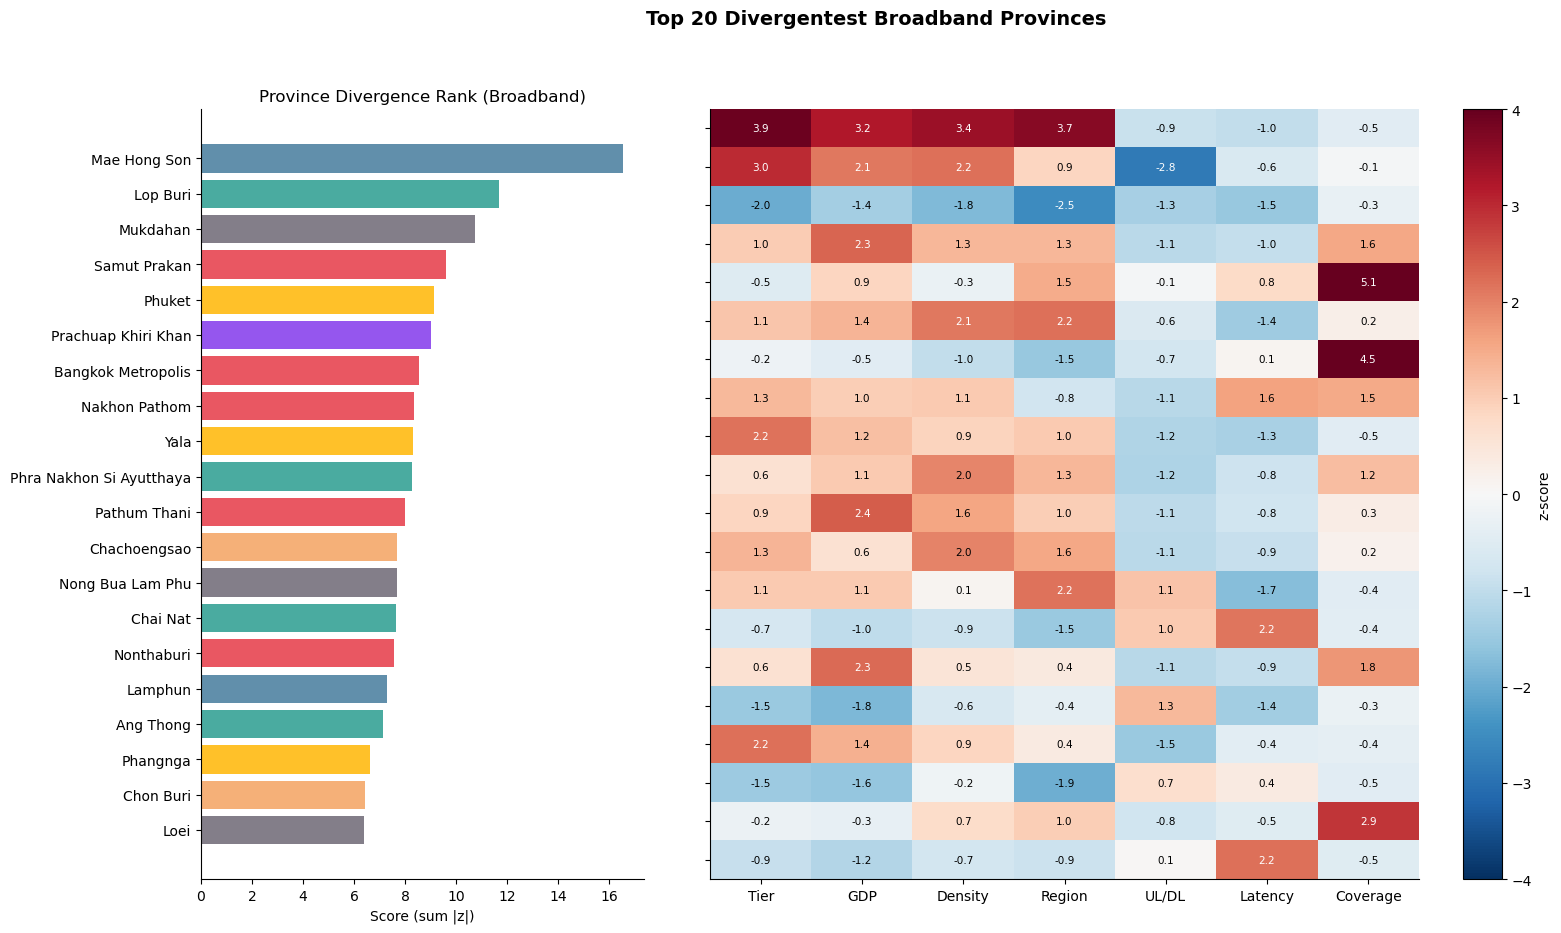

In [ ]:
def run_divergence(df, net_type):
    sub = df[df["network_type"] == net_type].copy().dropna(subset=["avg_d_mbps", "gdp_per_capita_thb_2021", "density_per_km2"])
    
    # 1. Tier gap
    tier_med = sub.groupby("internet_tier")["avg_d_mbps"].median()
    sub["tier_expected"] = sub["internet_tier"].map(tier_med)
    sub["tier_resid"] = (sub["avg_d_mbps"] - sub["tier_expected"]) / sub["tier_expected"]
    sub["tier_z"] = scipy_stats.zscore(sub["tier_resid"].fillna(0))
    
    # 2. GDP residual
    log_gdp = np.log(sub["gdp_per_capita_thb_2021"])
    s_g, i_g, _, _, _ = scipy_stats.linregress(log_gdp, sub["avg_d_mbps"])
    sub["gdp_expected"] = i_g + s_g * log_gdp
    sub["gdp_z"] = scipy_stats.zscore(sub["avg_d_mbps"] - sub["gdp_expected"])
    
    # 3. Density residual
    log_den = np.log1p(sub["density_per_km2"])
    s_d, i_d, _, _, _ = scipy_stats.linregress(log_den, sub["avg_d_mbps"])
    sub["den_expected"] = i_d + s_d * log_den
    sub["den_z"] = scipy_stats.zscore(sub["avg_d_mbps"] - sub["den_expected"])
    
    # 4. Regional Speed
    sub["regional_z"] = sub.groupby("region")["avg_d_mbps"].transform(
        lambda x: scipy_stats.zscore(x) if len(x) > 1 else pd.Series(np.zeros(len(x)), index=x.index)
    )
    
    # 5. Ratio
    sub["ratio_z"] = scipy_stats.zscore(sub["mean_ratio"])
    
    # 6. Latency
    sub["lat_z"] = sub.groupby("region")["avg_lat_ms"].transform(
        lambda x: scipy_stats.zscore(x.fillna(x.median())) if len(x) > 1 else pd.Series(np.zeros(len(x)), index=x.index)
    )
    
    # 7. Coverage
    sub["coverage_z"] = scipy_stats.zscore(sub["tests_per_1000_pop"])
    
    # Sum absolute z-scores
    sub["divergence_score"] = (
        sub["tier_z"].abs() +
        sub["gdp_z"].abs() +
        sub["den_z"].abs() +
        sub["regional_z"].abs() +
        sub["ratio_z"].abs() +
        sub["lat_z"].abs() +
        sub["coverage_z"].abs()
    )
    
    top20 = sub.nlargest(20, "divergence_score")
    
    fig = plt.figure(figsize=(18, 10))
    gs = fig.add_gridspec(1, 2, width_ratios=[1, 2], wspace=0.1)
    
    # Left Bar
    ax_bar = fig.add_subplot(gs[0])
    colors = [REGION_COLORS.get(r, "gray") for r in top20["region"]]
    ax_bar.barh(top20["province"], top20["divergence_score"], color=colors, alpha=0.85)
    ax_bar.invert_yaxis()
    ax_bar.set_xlabel("Score (sum |z|)")
    ax_bar.set_title(f"Province Divergence Rank ({net_type.title()})")
    
    # Right Heatmap
    ax_heat = fig.add_subplot(gs[1])
    dims = ["tier_z", "gdp_z", "den_z", "regional_z", "ratio_z", "lat_z", "coverage_z"]
    heat_data = top20[dims].values
    im = ax_heat.imshow(heat_data, cmap="RdBu_r", aspect="auto", vmin=-4, vmax=4)
    ax_heat.set_xticks(range(len(dims)))
    ax_heat.set_xticklabels(["Tier", "GDP", "Density", "Region", "UL/DL", "Latency", "Coverage"])
    ax_heat.set_yticks(range(len(top20)))
    ax_heat.set_yticklabels([])
    
    # Annotate numbers
    for i in range(len(top20)):
        for j in range(len(dims)):
            val = heat_data[i, j]
            txt_color = "white" if abs(val) > 2 else "black"
            ax_heat.text(j, i, f"{val:.1f}", ha="center", va="center", fontsize=7.5, color=txt_color)
            
    plt.colorbar(im, ax=ax_heat, label="z-score")
    plt.suptitle(f"Top 20 Divergentest {net_type.title()} Provinces", fontsize=14, fontweight="bold")
    plt.tight_layout()
    plt.show()

run_divergence(prov_master, "broadband")


## 21 — ISP Breakdown & Spatial-Bias Corrected Heatmaps
*M-Lab NDT7 standout feature: detailed performance breakdown per ISP and province using tile-level values.*


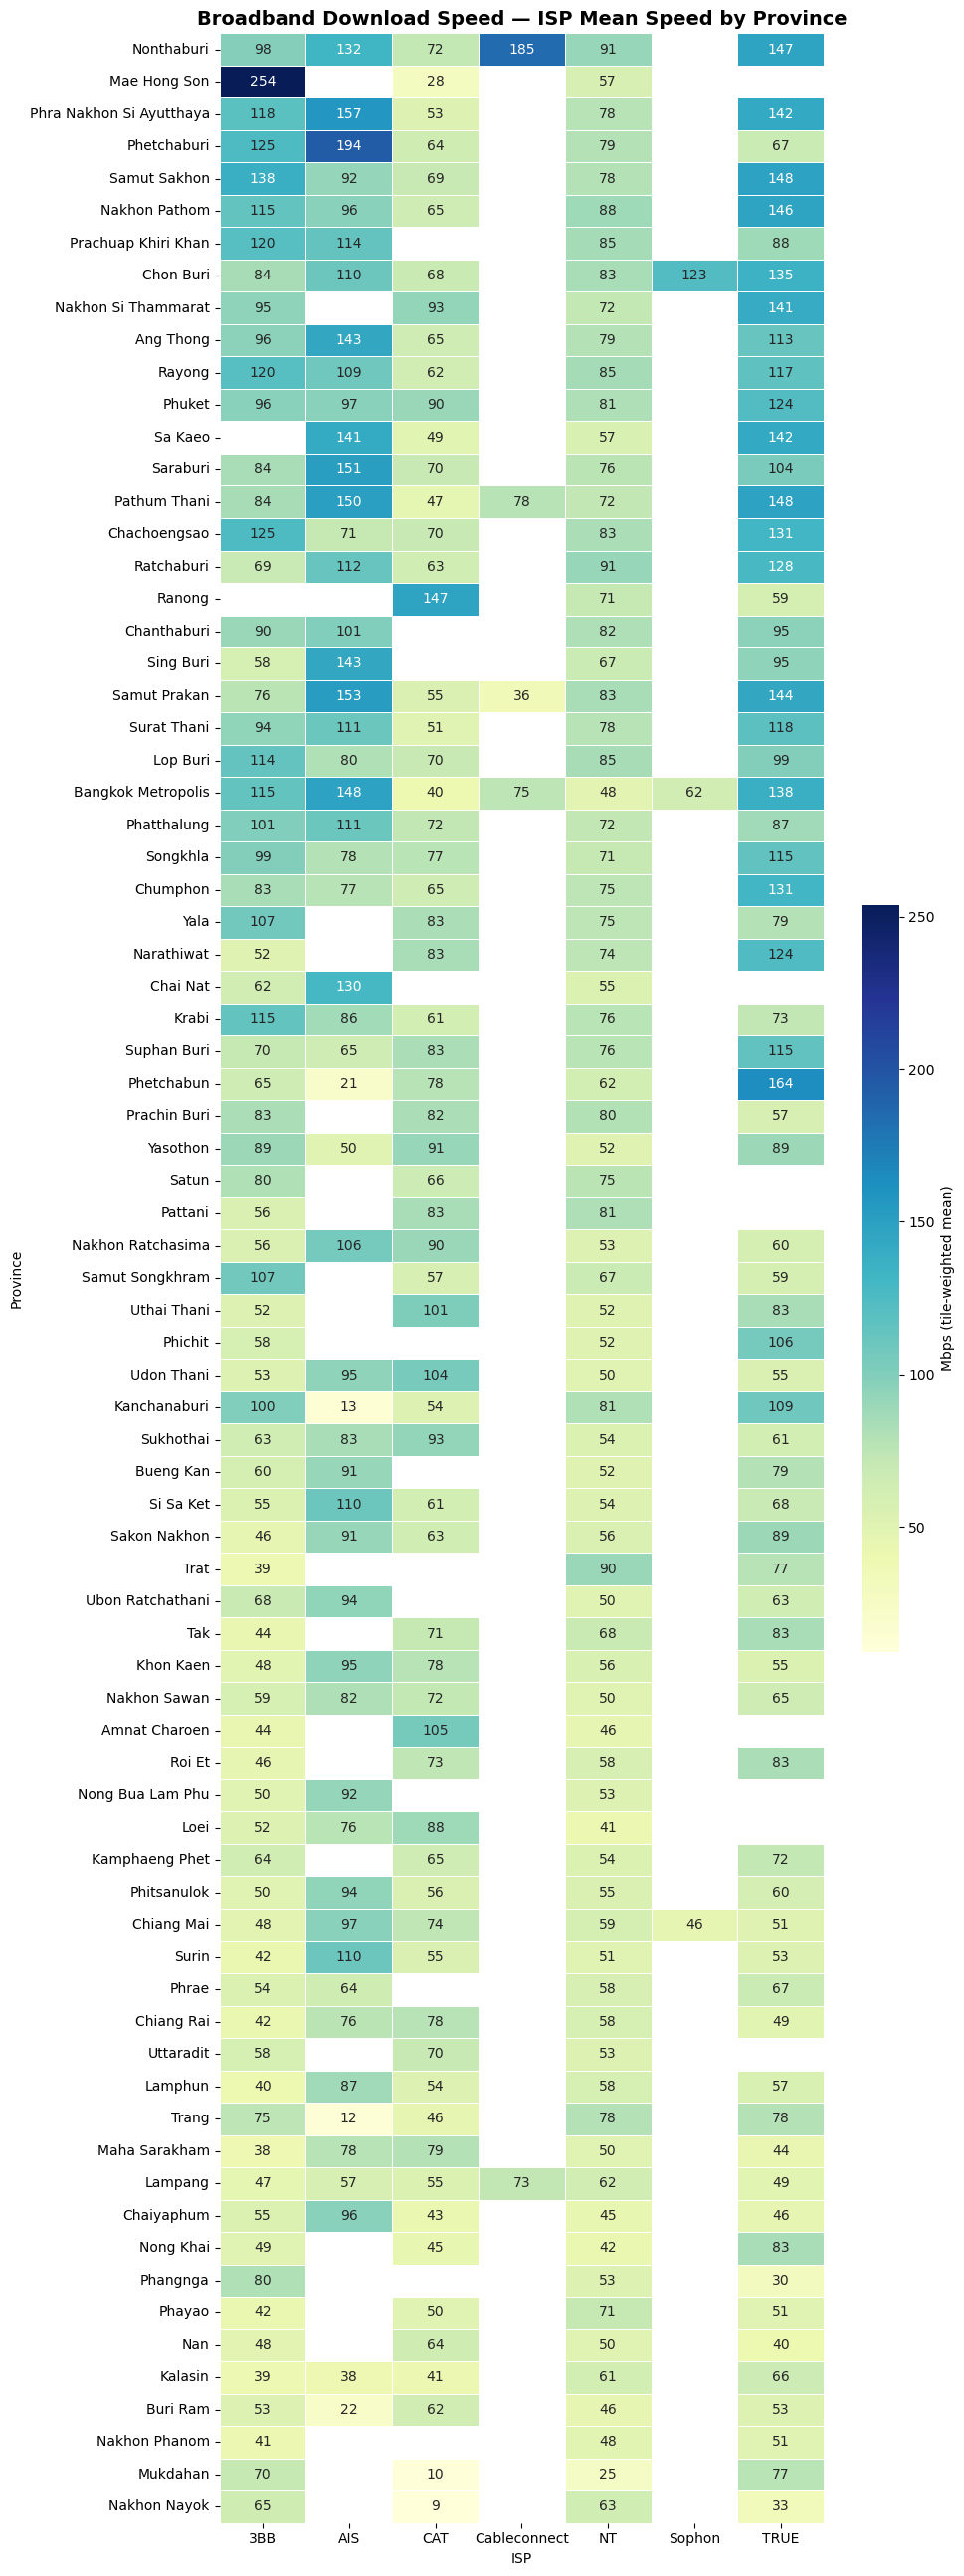

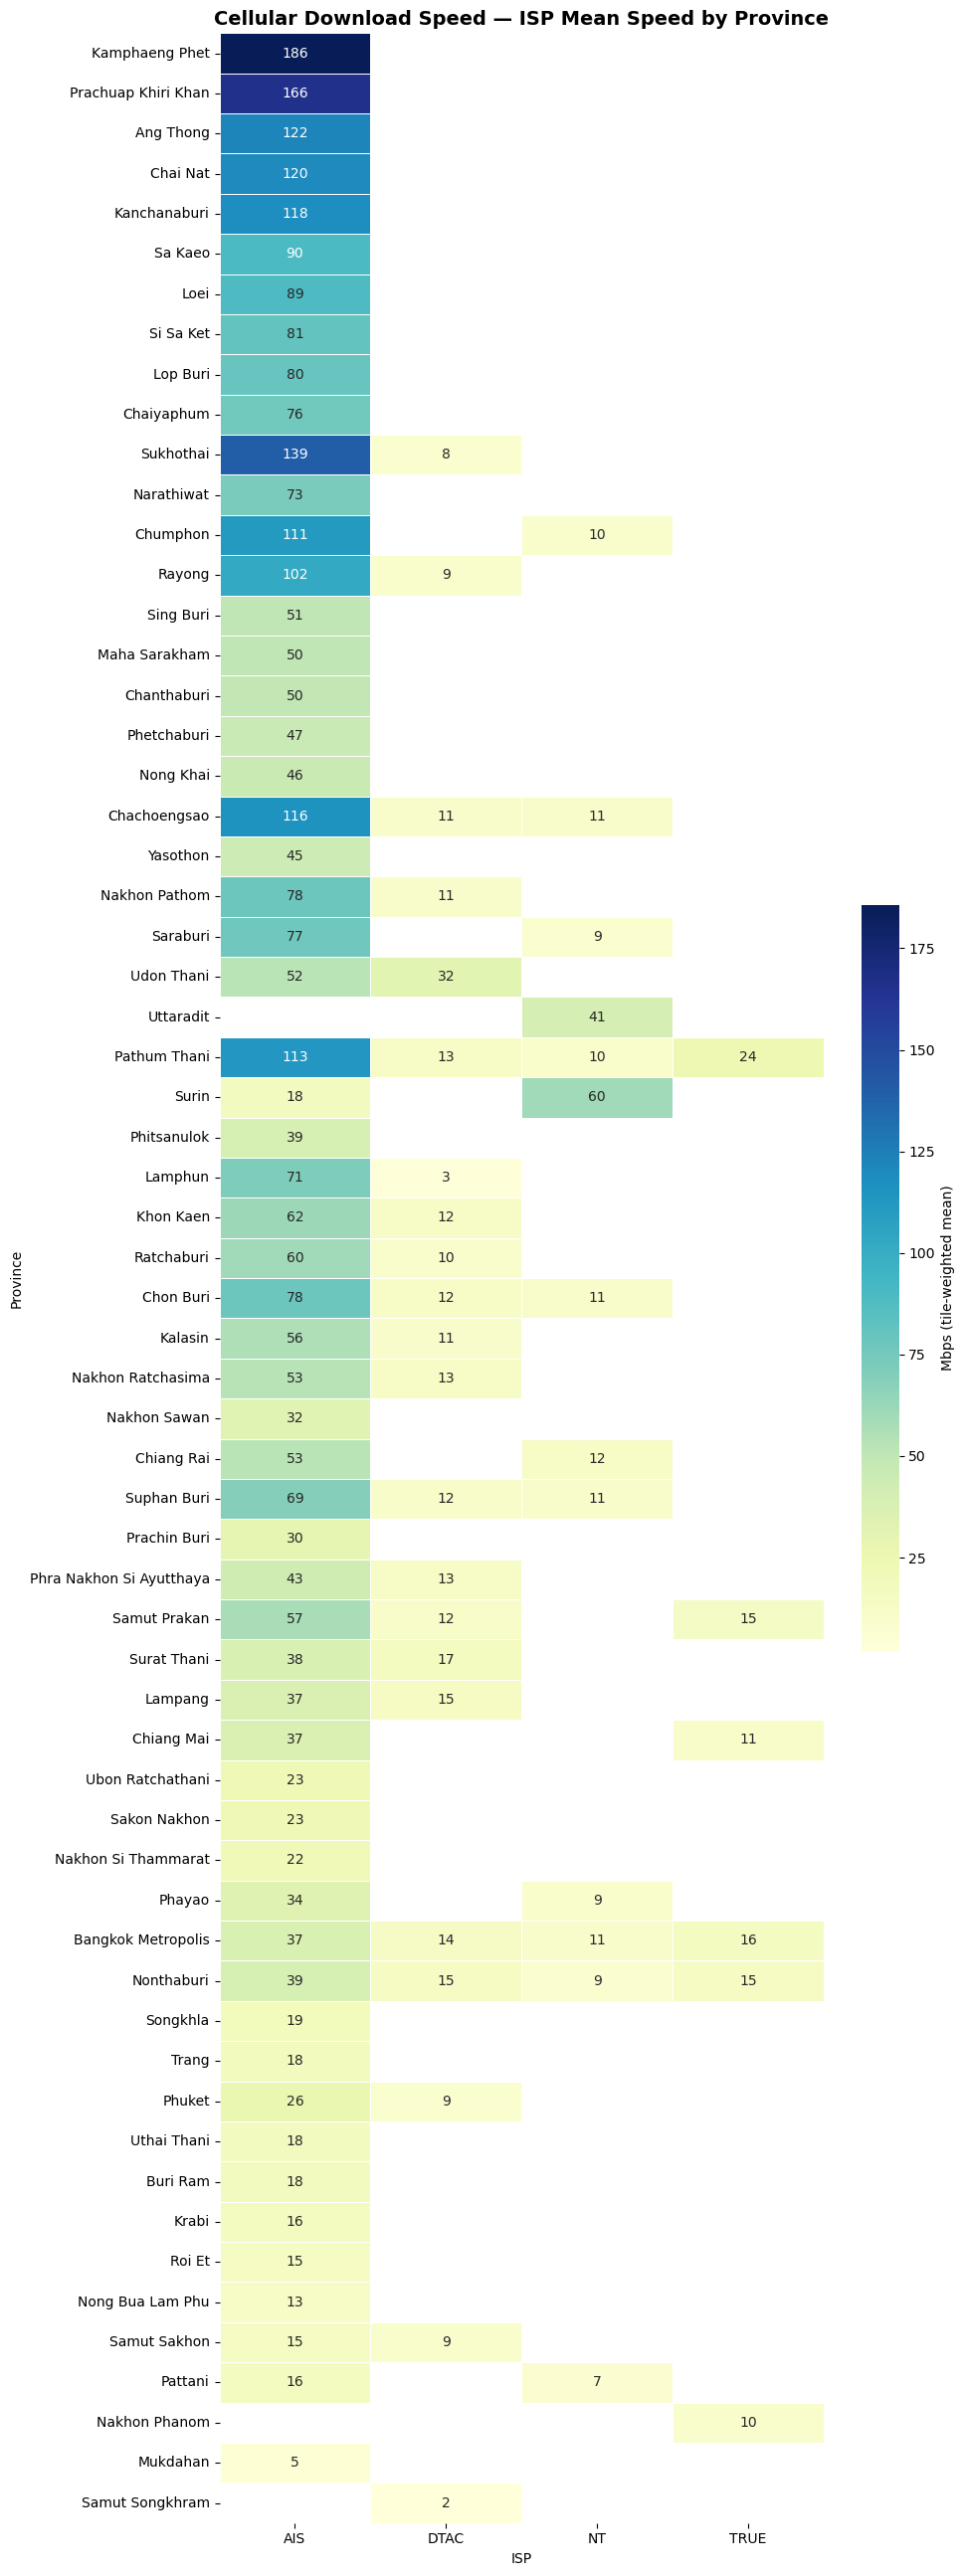

In [ ]:
def plot_isp_heatmaps(df, net_type):
    sub_df = df_full[df_full["network_type"] == net_type].copy()
    valid_isps = VALID_ISP_BB if net_type == "broadband" else VALID_ISP_CELL
    sub_df = sub_df[sub_df["description"].isin(valid_isps)]
    
    # Tile agg per ISP
    isp_tiles = sub_df.groupby(["description", "tile_id", "tile_x", "tile_y", "city"]).agg(
        tile_mean=("mean_throughput_mbps", "mean"),
        tile_count=("mean_throughput_mbps", "count")
    ).reset_index()
    isp_tiles = isp_tiles[isp_tiles["tile_count"] >= MIN_TILE_TESTS]
    
    # Spatial join
    n = 2**ZOOM
    tile_x_c = isp_tiles["tile_x"] + 0.5
    tile_y_c = isp_tiles["tile_y"] + 0.5
    lon_c = tile_x_c / n * 360 - 180
    lat_rad_c = np.arctan(np.sinh(np.pi * (1 - 2*tile_y_c/n)))
    lat_c = np.degrees(lat_rad_c)
    
    gdf_i = gpd.GeoDataFrame(isp_tiles.copy(), geometry=gpd.points_from_xy(lon_c, lat_c), crs="EPSG:4326")
    joined_i = gpd.sjoin(gdf_i, thai_gdf[["province_geo", "geometry"]], how="left", predicate="within")
    joined_i["province"] = joined_i["province_geo"].fillna(joined_i["city"])
    i_df = pd.DataFrame(joined_i.drop(columns=["geometry", "index_right", "province_geo", "city"], errors="ignore"))
    
    # Province agg per ISP
    isp_master = i_df.groupby(["description", "province"]).apply(lambda g: pd.Series({
        "mean_speed": np.average(g["tile_mean"], weights=g["tile_count"])
    }), include_groups=False).reset_index()
    
    pivot = isp_master.pivot(index="province", columns="description", values="mean_speed")
    pivot = pivot.loc[pivot.mean(axis=1).sort_values(ascending=False).index]
    
    fig, ax = plt.subplots(figsize=(10, 26))
    sns.heatmap(pivot, cmap="YlGnBu", annot=True, fmt=".0f", linewidths=0.5,
                cbar_kws={"label": "Mbps (tile-weighted mean)", "shrink": 0.3}, ax=ax)
    ax.set_title(f"{net_type.title()} Download Speed — ISP Mean Speed by Province", fontsize=14, fontweight="bold")
    ax.set_xlabel("ISP"); ax.set_ylabel("Province")
    plt.tight_layout()
    plt.show()

plot_isp_heatmaps(prov_master, "broadband")
plot_isp_heatmaps(prov_master, "cellular")


## 22 — Full Province Summary Table
*Print out of the final aggregated performance dataset for both Broadband and Cellular.*


In [ ]:
table_print = prov_master[["province", "region", "network_type", "avg_d_mbps", "med_d_mbps", "avg_u_mbps", "med_u_mbps", "avg_lat_ms", "total_tests"]].copy()
table_print = table_print.round(2)
print(table_print.to_string(index=False))


                province             region network_type  avg_d_mbps  med_d_mbps  avg_u_mbps  med_u_mbps  avg_lat_ms  total_tests
           Amnat Charoen       Northeastern    broadband       65.24       29.24       43.70       26.34      197.28       2550.0
               Ang Thong            Central    broadband      117.73       47.19       78.28       42.01       62.04       5037.0
      Bangkok Metropolis Bangkok & Vicinity    broadband      120.29       47.86       86.55       28.78       58.75    3875463.0
      Bangkok Metropolis Bangkok & Vicinity     cellular       27.77       10.77       12.52        4.55       59.88    7746497.0
               Bueng Kan       Northeastern    broadband       77.16       32.95       69.89       25.00      137.54       2180.0
                Buri Ram       Northeastern    broadband       52.03       26.80       41.43       15.34      157.77       8686.0
                Buri Ram       Northeastern     cellular       21.25       15.59       11.